In [1]:
# import requests

# url = "https://api.exchange.coinbase.com/products/btc-usd/candles?granularity=86400&start=2023-05-01T13:39:38.120597&end=2024-02-25T13:39:38.120597"

# response = requests.get(url)

# print(response.json())


### Retrieving Order Book Data from Coinbase

The following cell demonstrates how to retrieve a snapshot of the current order book from Coinbase using their public API. This API provides the current bids and asks for a given product (e.g., BTC-USD).

**Important Note:** This method provides a snapshot at the moment of the request. For continuous, historical order book data (often called Level 3 data), you would typically need to connect to a WebSocket feed and record the data stream over your desired period. The standard REST API is best for getting the current state of the order book.

In [ ]:
import requests
import json

# Define the product and API endpoint
product_id = "BTC-USD"
# Level 2 provides the top 50 bids and asks
url = f"https://api.exchange.coinbase.com/products/{product_id}/book?level=2"

# Make the request to the Coinbase API
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse the JSON response
    order_book = response.json()
    
    # Print the current order book
    print("Current BTC-USD Order Book:")
    print(json.dumps(order_book, indent=2))
    
    # You can also load this into a pandas DataFrame for easier analysis
    # bids_df = pd.DataFrame(order_book['bids'], columns=['price', 'size', 'num_orders'])
    # asks_df = pd.DataFrame(order_book['asks'], columns=['price', 'size', 'num_orders'])
    # print("\nBids:")
    # print(bids_df.head())
    # print("\nAsks:")
    # print(asks_df.head())
else:
    print(f"Failed to retrieve order book. Status code: {response.status_code}")
    print(response.text)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime
import pytz

# --- Fetching Historical Candlestick Data for a Specific Time ---

# Define the target time in EST
est = pytz.timezone('America/New_York')
start_time_est = est.localize(datetime(2024, 11, 15, 10, 0, 0))
end_time_est = est.localize(datetime(2024, 11, 15, 10, 10, 0))

# Convert to ISO 8601 format (which the API requires)
start_time_iso = start_time_est.isoformat()
end_time_iso = end_time_est.isoformat()

# Define the product, API endpoint, and granularity
product_id = "BTC-USD"
url = f"https://api.exchange.coinbase.com/products/{product_id}/candles"
granularity = 60  # 60 seconds = 1 minute candles

# Set up the parameters for the request
params = {
    "start": start_time_iso,
    "end": end_time_iso,
    "granularity": granularity
}

print(f"Requesting data for {product_id} from {start_time_iso} to {end_time_iso}...")

# Make the request to the Coinbase API
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    data = response.json()
    
    if data:
        # Convert to a pandas DataFrame
        # Columns: [time, low, high, open, close, volume]
        candles_df = pd.DataFrame(data, columns=['time', 'low', 'high', 'open', 'close', 'volume'])
        
        # Convert the 'time' column from Unix timestamp to a readable datetime format and set as index
        candles_df['time'] = pd.to_datetime(candles_df['time'], unit='s')
        candles_df = candles_df.set_index('time').sort_index()

        print(f"\nSuccessfully retrieved {len(candles_df)} one-minute candles for {product_id} around 2024-11-15 10:00 AM EST:")
        display(candles_df)
    else:
        print("\nNo data returned for the specified time period. This might be because it's a future date or a period with no trading.")

else:
    print(f"\nFailed to retrieve historical data. Status code: {response.status_code}")
    print(response.text)

### Fetching Historical Trade Data for a Specific Time

As mentioned, the standard Coinbase API does not provide historical order book snapshots. However, we can get the next best thing: historical trade data (candles) for a very specific time period.

The cell below is configured to fetch 1-minute candlestick data for **BTC-USD** on **November 15th, 2024, between 10:00 AM and 10:10 AM EST**. This provides a detailed view of the trading activity during that specific window.

In [3]:

data_df = pd.read_csv('data/btcusd_1-min_data.csv')
data_df['datetime'] = pd.to_datetime(data_df['Timestamp'],unit='s')
# restrcity to data after 2024-01-01
data_df = data_df[data_df['datetime'] >= '2024-01-01']

In [4]:
#feature engineering
data_df['close_chg'] = data_df['Close']/data_df['Close'].shift(1)-1

In [5]:
def volume_weight(df,numerator_window = 1,denominator_window=24*60): # numerator_window in minutes, denominator_window in minutes
    numerator = df['Volume'].rolling(numerator_window).sum()
    denominator = df['Volume'].rolling(denominator_window).sum()
    return numerator/denominator


In [6]:

def generate_return_volume_feature(data_df, feature_freq:int,denominator_window:int, prefix_str:str):

    # calcualte return of the specific frequency
    data_df[f'{prefix_str}_ret'] = data_df['Close'].pct_change(periods=feature_freq)
    # calculate volume of the period
    data_df[f'{prefix_str}_vol'] = data_df['Volume'].rolling(window=feature_freq).sum()
    # calculate volume weight
    data_df[f'{prefix_str}_vol_wt'] = volume_weight(data_df, numerator_window=feature_freq, denominator_window=denominator_window)
    # volume weighted return
    data_df[f'{prefix_str}_vol_wt_ret'] = data_df[f'{prefix_str}_ret'] * data_df[f'{prefix_str}_vol_wt']
    return data_df
data_df = generate_return_volume_feature(data_df, feature_freq=60, denominator_window=24*60, prefix_str='1h')
data_df = generate_return_volume_feature(data_df, feature_freq=60*24, denominator_window=7*24*60, prefix_str='1D') # daily feature with weekly volume weight


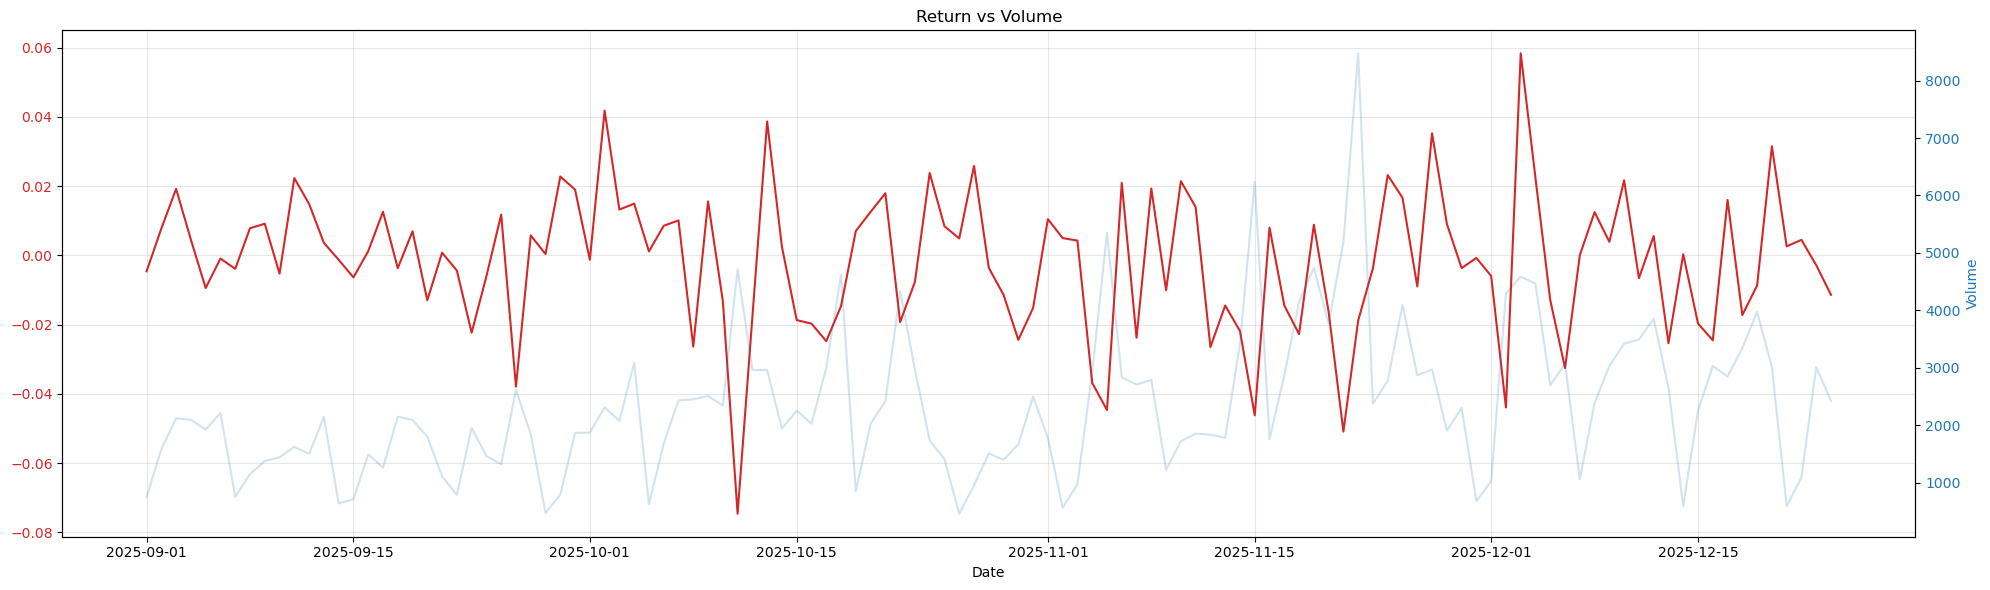

In [7]:
recent_df = data_df.loc[data_df['datetime']>'2025-09-01'].copy()
to_plot_df = recent_df[['datetime','Close','1D_ret','1D_vol']].copy().iloc[:-1:60*24, :]
# 2. Create the figure and the first axis
fig, ax1 = plt.subplots(figsize=(20, 6))

# 3. Plot 'hourly_ret' on the first axis (ax1)
color1 = 'tab:red'
ax1.set_xlabel('Date')
ax1.plot(to_plot_df['datetime'], to_plot_df['1D_ret'], color=color1, label='CLose Price')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# 4. Create a second axis that shares the same x-axis
ax2 = ax1.twinx()

# 5. Plot 'hour_vol' on the second axis (ax2)
color2 = 'tab:blue'
ax2.set_ylabel('Volume', color=color2)
ax2.plot(to_plot_df['datetime'], to_plot_df['1D_vol'], color=color2, label='Volume',alpha=0.2)
ax2.tick_params(axis='y', labelcolor=color2)

# 6. Add a title and adjust layout
plt.title('Return vs Volume')
fig.tight_layout()  # Adjusts layout to prevent clipping of labels
plt.show()

In [8]:
np.corrcoef(to_plot_df['1D_ret'].shift(-1).dropna(), to_plot_df['1D_vol'].dropna()[:-1])

array([[ 1.        , -0.00966145],
       [-0.00966145,  1.        ]])

### Intraday Volume Analysis

To understand if there are specific times of day that experience higher trading volume, which might be related to the trading hours of traditional markets and ETFs, let's start by analyzing the average trading volume for each hour of the day. We'll convert the timestamps to US Eastern Time (ET) to align with US market hours.

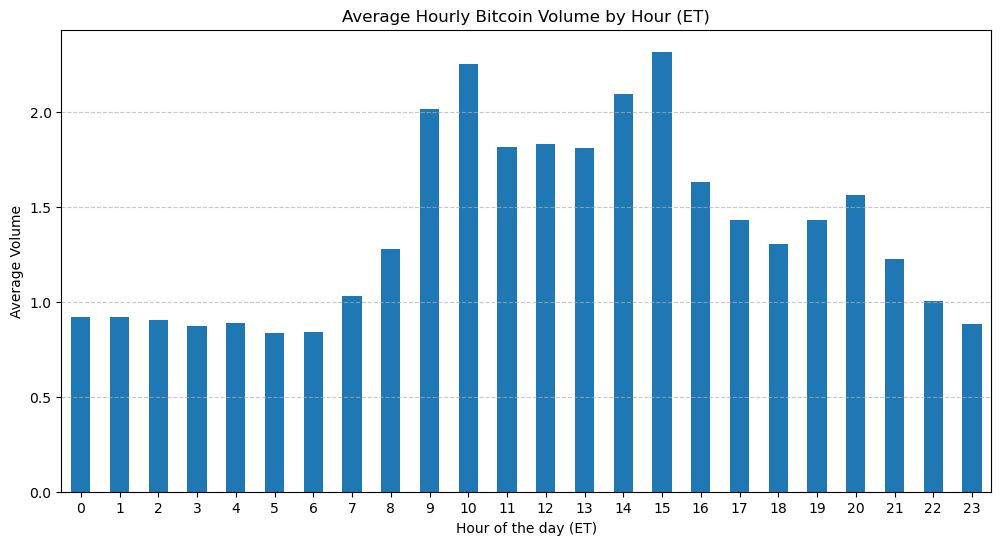

In [9]:
# Convert timestamp to ET and extract hour
data_df['datetime'] = pd.to_datetime(data_df['Timestamp'], unit='s', utc=True)
data_df['datetime_et'] = data_df['datetime'].dt.tz_convert('America/New_York')
data_df['hour_et'] = data_df['datetime_et'].dt.hour

# Group by hour and calculate average volume
hourly_volume = data_df.groupby('hour_et')['Volume'].mean()

# Plot the average hourly volume
plt.figure(figsize=(12, 6))
hourly_volume.plot(kind='bar')
plt.title('Average Hourly Bitcoin Volume by Hour (ET)')
plt.xlabel('Hour of the day (ET)')
plt.ylabel('Average Volume')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Predicting Future Returns with End-of-Day Volume

Now, let's investigate if the trading volume during the end of the US trading day has any predictive power for the next day's price movement. The hypothesis is that activity related to US-based ETFs, which can only trade during market hours, might contain signals about future price changes.

We will define "end-of-day volume" as the total volume during the last hour of the typical US stock market trading session (3:00 PM - 4:00 PM ET). We will then calculate the correlation between this end-of-day volume and the following day's return.

We will explore three variations of this feature:
1.  Raw end-of-day volume.
2.  End-of-day volume as a ratio of total daily volume.
3.  End-of-day volume anomaly (volume compared to its recent moving average).

In [10]:
# Define end of day volume as volume in the last hour of trading (15:00-15:59 ET)
end_of_day_volume = data_df[data_df['hour_et'] == 15].set_index('datetime_et').resample('D')['Volume'].sum()
end_of_day_volume.name = 'eod_volume'

# Resample the main dataframe to daily frequency to get daily close prices and total volume
daily_df = data_df.set_index('datetime_et').resample('D').agg({
    'Close': 'last',
    'Volume': 'sum'
}).rename(columns={'Volume': 'total_daily_volume'})

# Calculate next day's return using daily close prices and close at 9 am et and 15:00 et
daily_df['Close_9am'] = data_df[data_df['hour_et'] == 9].set_index('datetime_et').resample('D')['Close'].first()
daily_df['Close_3pm'] = data_df[data_df['hour_et'] == 15].set_index('datetime_et').resample('D')['Close'].last()
daily_df['next_trade_day_ret'] = daily_df['Close_3pm']/daily_df['Close_9am']-1
daily_df['next_day_ret'] = daily_df['Close'].pct_change().shift(-1)

# Merge the datasets
merged_df = pd.concat([daily_df, end_of_day_volume], axis=1).dropna()

# Calculate correlation for raw end-of-day volume
correlation_raw = merged_df['eod_volume'].corr(merged_df['next_day_ret'])
print(f"Correlation between raw end-of-day volume and next day's return: {correlation_raw:.4f}")

# Calculate end-of-day volume ratio
merged_df['eod_volume_ratio'] = merged_df['eod_volume'] / merged_df['total_daily_volume']
correlation_ratio = merged_df['eod_volume_ratio'].corr(merged_df['next_day_ret'])
print(f"Correlation between end-of-day volume ratio and next day's return: {correlation_ratio:.4f}")

# Calculate end-of-day volume anomaly
merged_df['eod_volume_ma'] = merged_df['eod_volume'].rolling(window=30).mean()
merged_df['eod_volume_anomaly'] = merged_df['eod_volume'] / merged_df['eod_volume_ma']
correlation_anomaly = merged_df.dropna()['eod_volume_anomaly'].corr(merged_df.dropna()['next_day_ret'])
print(f"Correlation between end-of-day volume anomaly and next day's return: {correlation_anomaly:.4f}")

Correlation between raw end-of-day volume and next day's return: -0.0076
Correlation between end-of-day volume ratio and next day's return: -0.0601
Correlation between end-of-day volume anomaly and next day's return: -0.0068


### Focused Test: Last Hour Volume Ratio vs. Next Day Return

Here is a specific test to isolate and verify the correlation between the last hour's volume ratio and the subsequent day's price return. As before, the "last hour" is defined as 3:00 PM to 4:00 PM ET to align with the closing of US markets, which is a critical time for ETF-related trading activity.

In [11]:

# Isolate the data for the last hour of the trading day (3:00 PM - 4:00 PM ET)
last_hour_volume = data_df[data_df['hour_et'] == 15].set_index('datetime_et').resample('D')['Volume'].sum()
last_hour_volume.name = 'last_hour_volume'

# last hour return
last_hour_return = data_df[data_df['hour_et'] == 15].set_index('datetime_et').resample('D')['Close'].apply(lambda x: x.iloc[-1]/x.iloc[0]-1)
last_hour_return.name = 'last_hour_return'

# average hourly return of the day
# compute hourly closes first, then pct_change to avoid resampler/pct_change mismatch
hourly_close = data_df.set_index('datetime_et')['Close'].resample('H').last()
hourly_returns = hourly_close.pct_change()
daily_hourly_mean_returns = hourly_returns.resample('D').mean()
daily_hourly_std_returns = hourly_returns.resample('D').std()
hourly_returns.name = 'hourly_returns'
daily_hourly_mean_returns.name = 'daily_hourly_mean_returns'
daily_hourly_std_returns.name = 'daily_hourly_std_returns'

# Calculate total daily volume
daily_volume = data_df.set_index('datetime_et').resample('D')['Volume'].sum()
daily_volume.name = 'total_daily_volume'

# Calculate the daily close and the next day's return
daily_returns = data_df.set_index('datetime_et').resample('D')['Close'].last().pct_change().shift(-1)
daily_returns.name = 'next_day_return' 

# Calculate the daily close at 9 am et and 3 pm et and next trade day return
daily_close_9am = data_df[data_df['hour_et'] == 9].set_index('datetime_et').resample('D')['Close'].first()
daily_close_3pm = data_df[data_df['hour_et'] == 15].set_index('datetime_et').resample('D')['Close'].last()
daily_close_9am.name = 'daily_close_9am'
daily_close_3pm.name = 'daily_close_3pm'
next_trade_day_return = daily_close_3pm.pct_change().shift(-1)
next_trade_day_return.name = 'next_trade_day_ret'

# Combine into a single DataFrame
analysis_df = pd.concat([last_hour_volume, last_hour_return, daily_volume, daily_returns,next_trade_day_return, daily_hourly_mean_returns, daily_hourly_std_returns], axis=1).dropna()
analysis_df['last_hour_ret_dev'] = (analysis_df['last_hour_return'] - analysis_df['daily_hourly_mean_returns']) / analysis_df['daily_hourly_std_returns']

# Calculate the last hour volume ratio
analysis_df['last_hour_volume_ratio'] = analysis_df['last_hour_volume'] / analysis_df['total_daily_volume']

# Calculate the correlation between the ratio and the next day's return
correlation = analysis_df['last_hour_volume_ratio'].corr(analysis_df['next_day_return'])
print(f"Correlation between last hour volume ratio and next day's return: {correlation:.4f}")

# Filtered correlation: ensure both series are filtered the same way to avoid mismatched lengths
filtered = analysis_df[analysis_df['last_hour_volume_ratio'] > 0.2]
print(f"Number of days with last hour volume ratio > 0.2: {len(filtered)}")
correlation_filtered = filtered['last_hour_volume_ratio'].corr(filtered['next_day_return'])
print(f"Correlation (last hour volume ratio > 0.2) between last hour volume ratio and next day's return: {correlation_filtered:.4f}")

# last hour return deviation correlation
correlation_ret_dev = analysis_df['last_hour_ret_dev'].corr(analysis_df['next_day_return'])
print(f"Correlation between last hour return deviation and next day's return: {correlation_ret_dev:.4f}")

Correlation between last hour volume ratio and next day's return: -0.0594
Number of days with last hour volume ratio > 0.2: 18
Correlation (last hour volume ratio > 0.2) between last hour volume ratio and next day's return: 0.2093
Correlation between last hour return deviation and next day's return: 0.0083


<Axes: >

<Axes: >

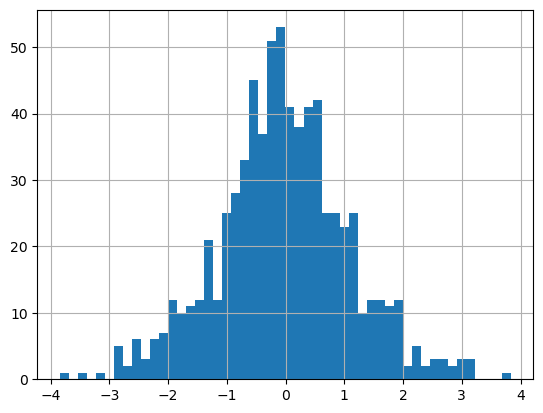

In [12]:
analysis_df['last_hour_ret_dev'].hist(bins=50)

### Volatility and Volume Clustering Analysis

Volatility clustering is a well-known phenomenon in financial markets where periods of high volatility are followed by other periods of high volatility, and periods of low volatility are followed by periods of low volatility. Similarly, trading volumes can exhibit clustering.

To test for this, we can examine the autocorrelation of the absolute (or squared) returns and the autocorrelation of trading volume. If significant autocorrelation is present, it suggests the presence of clustering.

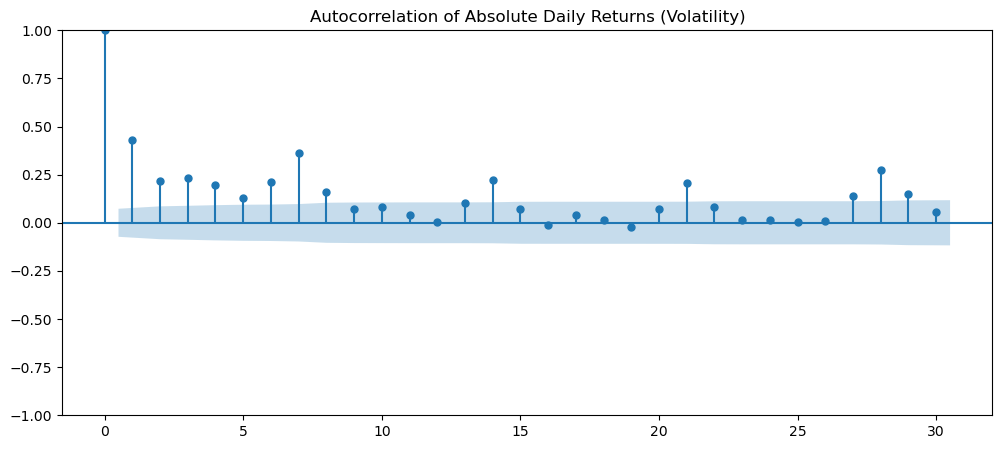

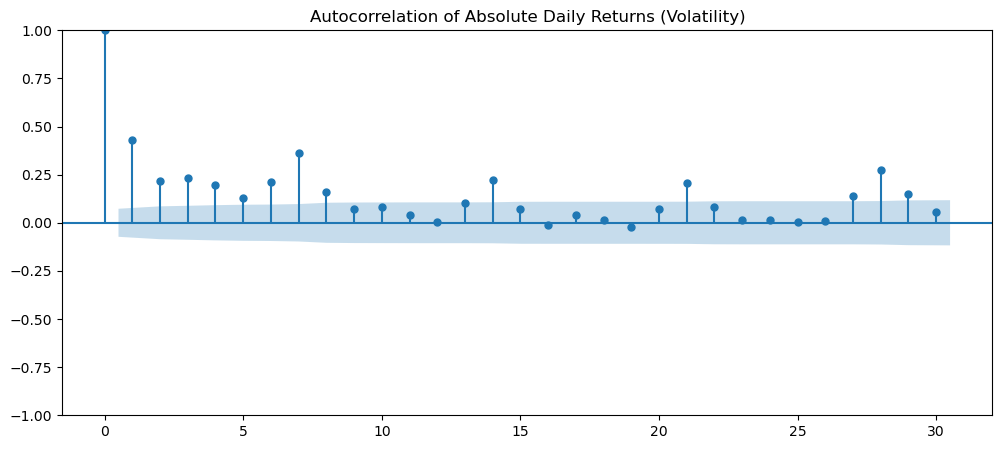

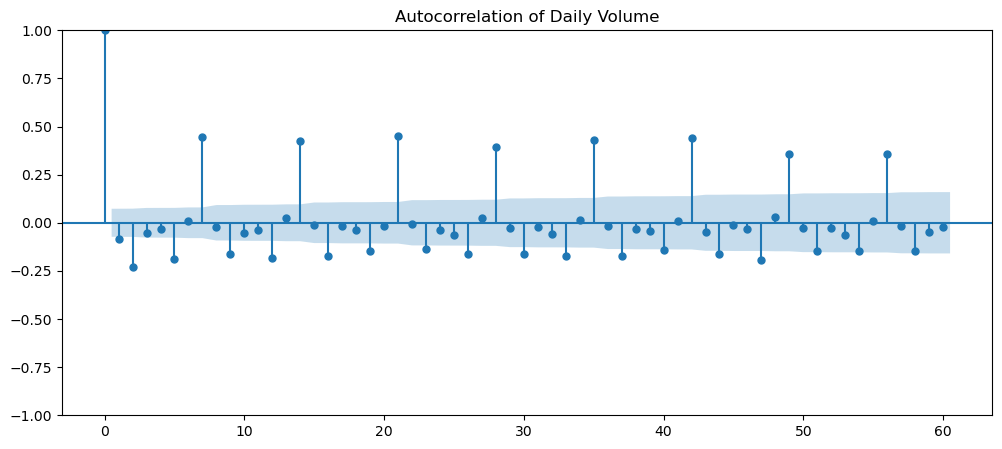

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot autocorrelation of absolute returns
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(analysis_df['daily_hourly_std_returns'], lags=30, ax=ax)
ax.set_title('Autocorrelation of Absolute Daily Returns (Volatility)')
plt.show()

# --- Volume Clustering Test ---
daily_volume = daily_df['total_daily_volume'].pct_change().dropna()

# Plot autocorrelation of daily volume
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(daily_volume, lags=60, ax=ax)
ax.set_title('Autocorrelation of Daily Volume')
plt.show()

Dominant cycle period (days, composite price+volume): 241.67
Correlation between composite cycle factor and next day's return: 0.1077


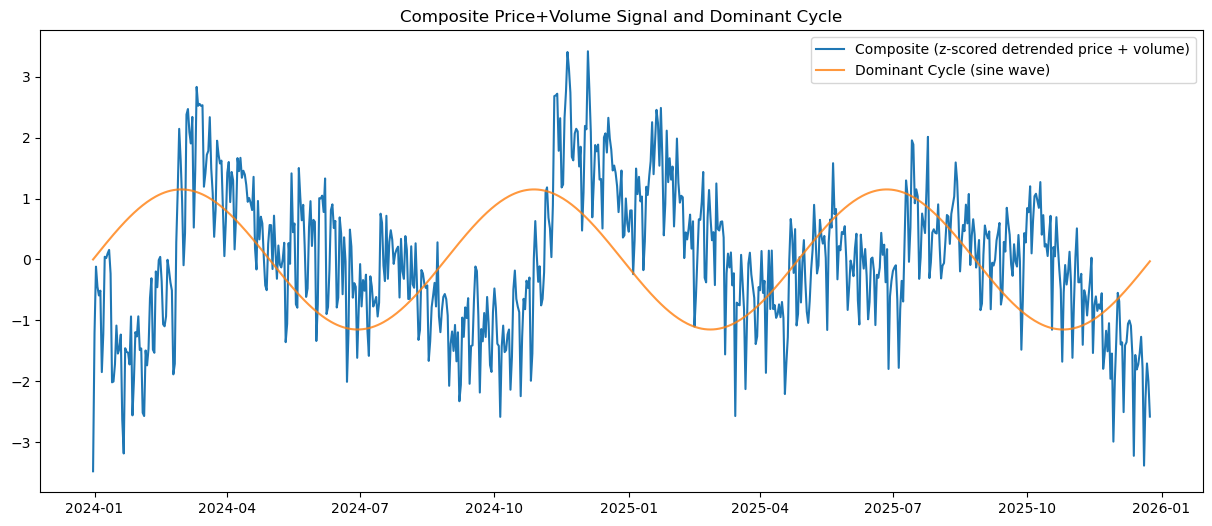

In [14]:
from scipy.signal import detrend
from scipy.fft import fft, fftfreq
from scipy.stats import zscore

# Use daily close prices and drop any missing values
close_prices = daily_df['Close'].dropna()
# daily volume (ensure aligned with close prices)
daily_vol = daily_df['total_daily_volume'].reindex(close_prices.index).fillna(method='ffill')

# Detrend the log-transformed price series to focus on cycles
log_prices = np.log(close_prices)
detrended_log_prices = detrend(log_prices)

# Prepare z-scored signals: price (detrended) and volume (log + zscore)
price_z = zscore(detrended_log_prices)
vol_z = zscore(np.log1p(daily_vol.values))

# Composite signal: combine price and volume information (tune weight if desired)
alpha = 0.7  # weight for volume contribution; adjust if needed
composite = pd.Series(price_z + alpha * vol_z, index=close_prices.index).dropna()

# Apply Fast Fourier Transform (FFT) on composite signal to find dominant cycle
N = len(composite)
yf = fft(composite.values)
xf = fftfreq(N, 1)[:N//2]  # Frequency axis (1 day sample spacing)

# Calculate power and identify dominant non-zero frequency
power = np.abs(yf[:N//2])**2
if N < 3:
    dominant_period = np.nan
else:
    # ignore zero-frequency component when searching for dominant
    dominant_idx = np.argmax(power[1:]) + 1
    dominant_freq = xf[dominant_idx]
    dominant_period = np.nan if dominant_freq == 0 else 1.0 / np.abs(dominant_freq)

print(f"Dominant cycle period (days, composite price+volume): {dominant_period:.2f}")

# Create a cyclical factor based on the dominant cycle (sine wave scaled to composite std)
if np.isfinite(dominant_period):
    days = np.arange(N)
    cycle_factor = pd.Series(np.sin(2 * np.pi * days / dominant_period) * composite.std(), index=composite.index)
    cycle_factor.name = 'cycle_factor'
else:
    cycle_factor = pd.Series(0, index=composite.index)
    cycle_factor.name = 'cycle_factor'

# Merge with analysis_df and calculate correlation (align indices)
analysis_df_with_cycle = analysis_df.join(cycle_factor, how='inner').dropna()
correlation_cycle = analysis_df_with_cycle['cycle_factor'].corr(analysis_df_with_cycle['next_day_return'])

print(f"Correlation between composite cycle factor and next day's return: {correlation_cycle:.4f}")

# Plot the composite signal and the identified cycle
plt.figure(figsize=(15, 6))
plt.plot(composite.index, composite.values, label='Composite (z-scored detrended price + volume)')
if np.isfinite(dominant_period):
    plt.plot(cycle_factor.index, cycle_factor, label='Dominant Cycle (sine wave)', alpha=0.8)
plt.title('Composite Price+Volume Signal and Dominant Cycle')
plt.legend()
plt.show()

--- Weekday statistics ---
               mean       std  count       sem
weekday                                       
Monday     0.003904  0.031239    104  0.003063
Tuesday   -0.001488  0.027703    104  0.002716
Wednesday  0.007875  0.028390    104  0.002784
Thursday  -0.003088  0.025625    103  0.002525
Friday     0.000226  0.024912    103  0.002455
Saturday   0.000773  0.012355    103  0.001217
Sunday     0.001069  0.023740    103  0.002339

--- T-test weekday vs 0 ---
Monday: t=1.275, p=0.205, n=104
Tuesday: t=-0.548, p=0.585, n=104
Wednesday: t=2.829, p=0.006, n=104
Thursday: t=-1.223, p=0.224, n=103
Friday: t=0.092, p=0.927, n=103
Saturday: t=0.635, p=0.527, n=103
Sunday: t=0.457, p=0.649, n=103

ANOVA F=2.089, p=0.052


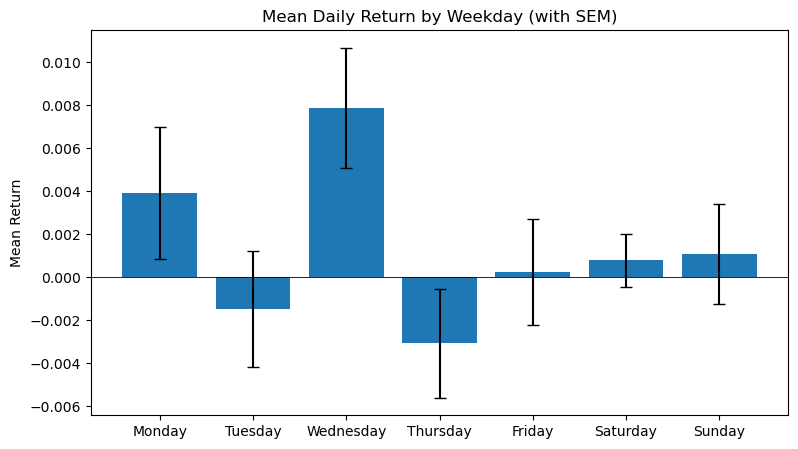

--- Weekday statistics ---
               mean       std  count       sem
weekday                                       
Monday     0.003904  0.031239    104  0.003063
Tuesday   -0.001488  0.027703    104  0.002716
Wednesday  0.007875  0.028390    104  0.002784
Thursday  -0.003088  0.025625    103  0.002525
Friday     0.000226  0.024912    103  0.002455
Saturday   0.000773  0.012355    103  0.001217
Sunday     0.001069  0.023740    103  0.002339

--- T-test weekday vs 0 ---
Monday: t=1.275, p=0.205, n=104
Tuesday: t=-0.548, p=0.585, n=104
Wednesday: t=2.829, p=0.006, n=104
Thursday: t=-1.223, p=0.224, n=103
Friday: t=0.092, p=0.927, n=103
Saturday: t=0.635, p=0.527, n=103
Sunday: t=0.457, p=0.649, n=103

ANOVA F=2.089, p=0.052


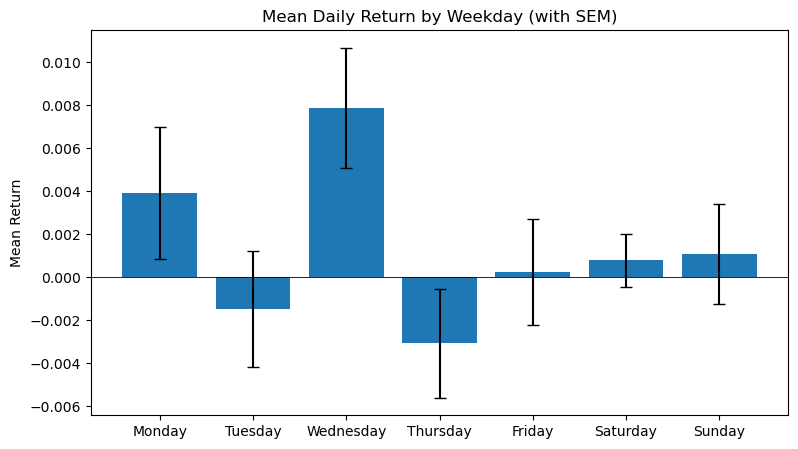


--- Month statistics ---
               mean       std  count       sem
month                                         
January    0.001918  0.025653     62  0.003258
February   0.003774  0.029466     57  0.003903
March      0.002528  0.036894     62  0.004686
April     -0.000071  0.028429     60  0.003670
May        0.003600  0.023371     62  0.002968
June      -0.000701  0.016457     60  0.002125
July       0.001923  0.020881     62  0.002652
August    -0.002239  0.028145     62  0.003574
September  0.002430  0.018277     60  0.002360
October    0.000983  0.020290     62  0.002577
November   0.001803  0.030042     60  0.003878
December   0.000040  0.023634     55  0.003187


--- Weekday statistics ---
               mean       std  count       sem
weekday                                       
Monday     0.003904  0.031239    104  0.003063
Tuesday   -0.001488  0.027703    104  0.002716
Wednesday  0.007875  0.028390    104  0.002784
Thursday  -0.003088  0.025625    103  0.002525
Friday     0.000226  0.024912    103  0.002455
Saturday   0.000773  0.012355    103  0.001217
Sunday     0.001069  0.023740    103  0.002339

--- T-test weekday vs 0 ---
Monday: t=1.275, p=0.205, n=104
Tuesday: t=-0.548, p=0.585, n=104
Wednesday: t=2.829, p=0.006, n=104
Thursday: t=-1.223, p=0.224, n=103
Friday: t=0.092, p=0.927, n=103
Saturday: t=0.635, p=0.527, n=103
Sunday: t=0.457, p=0.649, n=103

ANOVA F=2.089, p=0.052


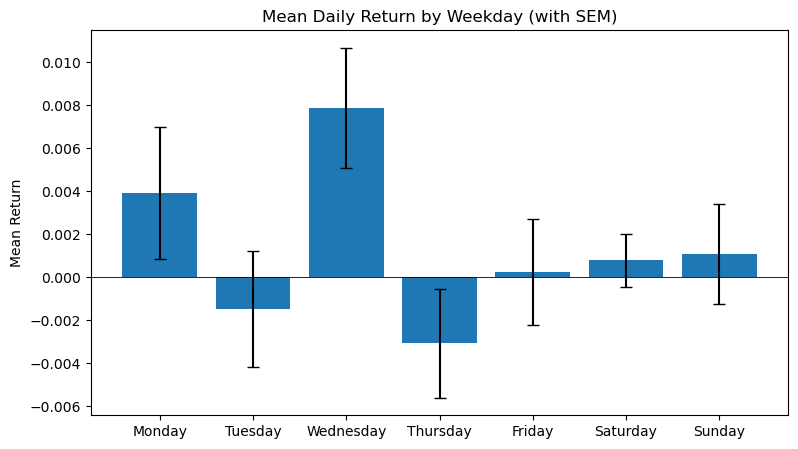


--- Month statistics ---
               mean       std  count       sem
month                                         
January    0.001918  0.025653     62  0.003258
February   0.003774  0.029466     57  0.003903
March      0.002528  0.036894     62  0.004686
April     -0.000071  0.028429     60  0.003670
May        0.003600  0.023371     62  0.002968
June      -0.000701  0.016457     60  0.002125
July       0.001923  0.020881     62  0.002652
August    -0.002239  0.028145     62  0.003574
September  0.002430  0.018277     60  0.002360
October    0.000983  0.020290     62  0.002577
November   0.001803  0.030042     60  0.003878
December   0.000040  0.023634     55  0.003187


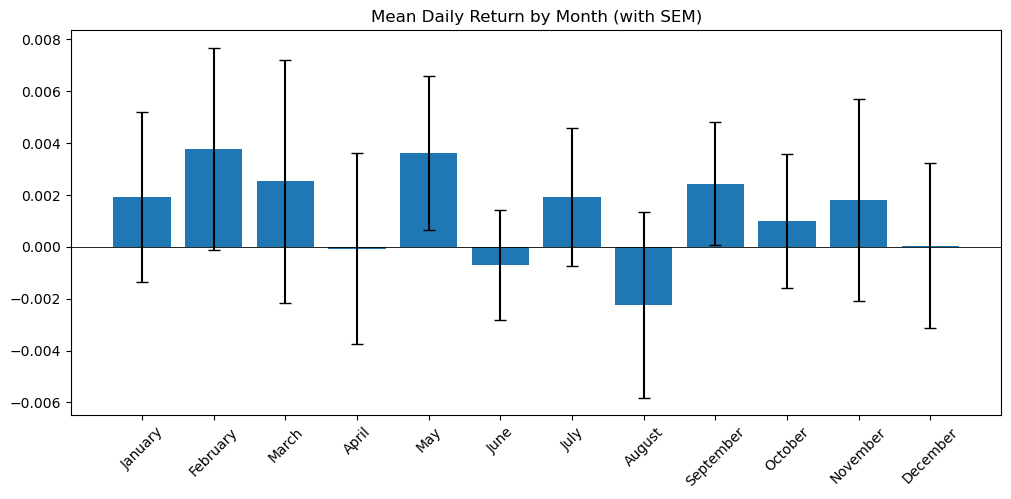

--- Weekday statistics ---
               mean       std  count       sem
weekday                                       
Monday     0.003904  0.031239    104  0.003063
Tuesday   -0.001488  0.027703    104  0.002716
Wednesday  0.007875  0.028390    104  0.002784
Thursday  -0.003088  0.025625    103  0.002525
Friday     0.000226  0.024912    103  0.002455
Saturday   0.000773  0.012355    103  0.001217
Sunday     0.001069  0.023740    103  0.002339

--- T-test weekday vs 0 ---
Monday: t=1.275, p=0.205, n=104
Tuesday: t=-0.548, p=0.585, n=104
Wednesday: t=2.829, p=0.006, n=104
Thursday: t=-1.223, p=0.224, n=103
Friday: t=0.092, p=0.927, n=103
Saturday: t=0.635, p=0.527, n=103
Sunday: t=0.457, p=0.649, n=103

ANOVA F=2.089, p=0.052


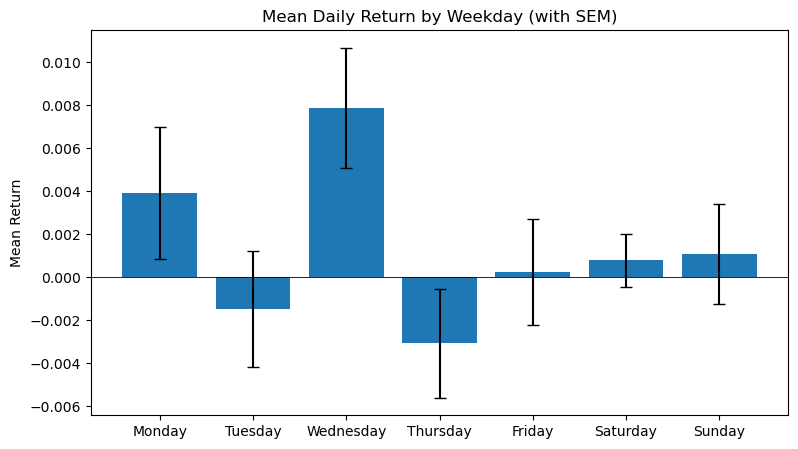


--- Month statistics ---
               mean       std  count       sem
month                                         
January    0.001918  0.025653     62  0.003258
February   0.003774  0.029466     57  0.003903
March      0.002528  0.036894     62  0.004686
April     -0.000071  0.028429     60  0.003670
May        0.003600  0.023371     62  0.002968
June      -0.000701  0.016457     60  0.002125
July       0.001923  0.020881     62  0.002652
August    -0.002239  0.028145     62  0.003574
September  0.002430  0.018277     60  0.002360
October    0.000983  0.020290     62  0.002577
November   0.001803  0.030042     60  0.003878
December   0.000040  0.023634     55  0.003187


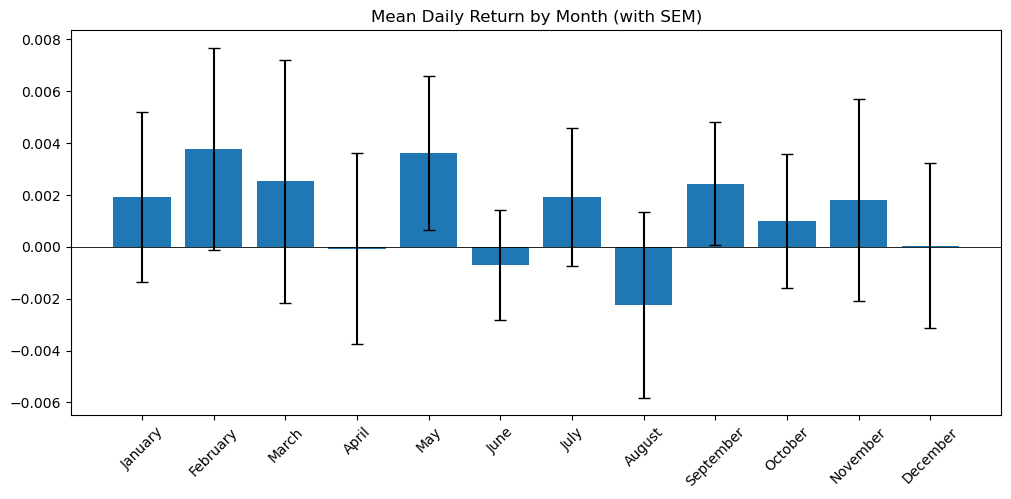

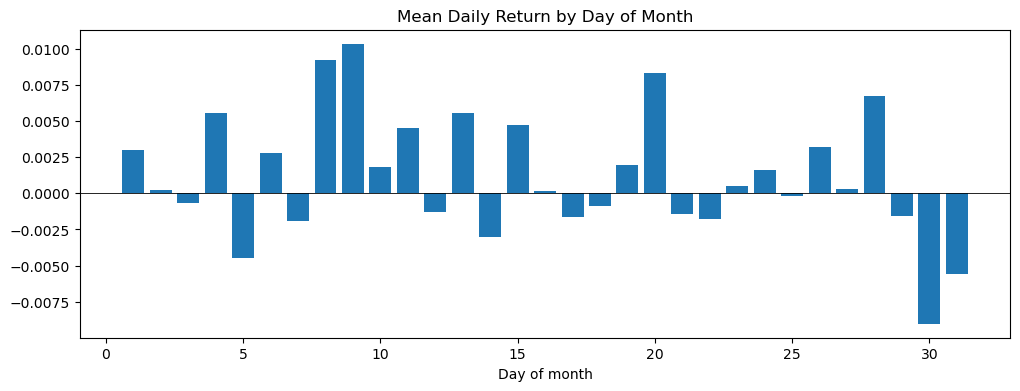


Calendar effects analysis complete.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, f_oneway

# --- Calendar effects analysis on daily returns ---
daily_close = daily_df['Close'].dropna()
daily_ret = daily_close.pct_change().dropna()
cal_df = pd.DataFrame({'daily_return': daily_ret})
cal_df['weekday'] = cal_df.index.day_name()
cal_df['month'] = cal_df.index.month_name()
cal_df['day'] = cal_df.index.day

# Weekday analysis
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wk_stats = cal_df.groupby('weekday')['daily_return'].agg(['mean','std','count']).reindex(weekday_order)
wk_stats['sem'] = wk_stats['std']/np.sqrt(wk_stats['count'])
print('--- Weekday statistics ---')
print(wk_stats)

# t-tests vs zero for each weekday
tt = []
for wd in weekday_order:
    vals = cal_df[cal_df['weekday']==wd]['daily_return'].values
    if len(vals)>1:
        stat,p = ttest_1samp(vals, 0.0, nan_policy='omit')
    else:
        stat,p = (np.nan,np.nan)
    tt.append((wd,stat,p,len(vals)))
print('\n--- T-test weekday vs 0 ---')
for r in tt: print(f"{r[0]}: t={r[1]:.3f}, p={r[2]:.3f}, n={r[3]}")

# ANOVA across weekdays
groups = [cal_df[cal_df['weekday']==wd]['daily_return'].dropna().values for wd in weekday_order if len(cal_df[cal_df['weekday']==wd])>1]
if len(groups)>1:
    fstat, fp = f_oneway(*groups)
    print(f"\nANOVA F={fstat:.3f}, p={fp:.3f}")
else:
    print('\nNot enough data for ANOVA')

# Plot weekday mean returns with SEM error bars
plt.figure(figsize=(9,5))
plt.bar(wk_stats.index, wk_stats['mean'], yerr=wk_stats['sem'], capsize=4)
plt.axhline(0, color='k', linewidth=0.6)
plt.title('Mean Daily Return by Weekday (with SEM)')
plt.ylabel('Mean Return')
plt.show()

# Month analysis
months = ['January','February','March','April','May','June','July','August','September','October','November','December']
mo_stats = cal_df.groupby('month')['daily_return'].agg(['mean','std','count']).reindex(months).dropna()
mo_stats['sem'] = mo_stats['std']/np.sqrt(mo_stats['count'])
print('\n--- Month statistics ---')
print(mo_stats)

plt.figure(figsize=(12,5))
plt.bar(mo_stats.index, mo_stats['mean'], yerr=mo_stats['sem'], capsize=4)
plt.axhline(0, color='k', linewidth=0.6)
plt.title('Mean Daily Return by Month (with SEM)')
plt.xticks(rotation=45)
plt.show()

# Day-of-month effects (1-31)
day_stats = cal_df.groupby('day')['daily_return'].agg(['mean','count']).reindex(range(1,32)).fillna(0)
plt.figure(figsize=(12,4))
plt.bar(day_stats.index, day_stats['mean'])
plt.axhline(0, color='k', linewidth=0.6)
plt.title('Mean Daily Return by Day of Month')
plt.xlabel('Day of month')
plt.show()

print('\nCalendar effects analysis complete.')

Volume-based factors calculated.


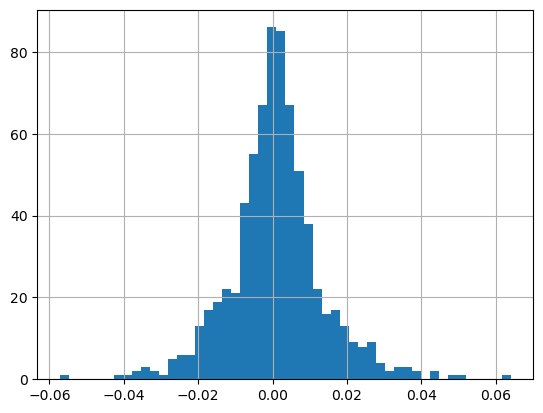

In [16]:
# --- Volume-Based Factors ---

# Calculate daily VWAP from minute data
data_df['price_vol'] = data_df['Close'] * data_df['Volume']
vwap_daily_sum = data_df.set_index('datetime_et')[['price_vol', 'Volume']].resample('D').sum()
vwap_daily = vwap_daily_sum['price_vol'] / vwap_daily_sum['Volume']
vwap_daily.name = 'vwap'

# Calculate deviation of close price from VWAP
price_vwap_dev = (daily_df['Close'] - vwap_daily) / vwap_daily
price_vwap_dev.name = 'price_vwap_dev'
price_vwap_dev.hist(bins=50)
# Calculate On-Balance Volume (OBV)
obv = (np.sign(daily_df['Close'].diff()) * daily_df['total_daily_volume']).fillna(0).cumsum()
obv.name = 'obv'

print("Volume-based factors calculated.")

In [17]:
# --- Momentum Factors ---

# Use daily close prices for momentum indicators
close_prices = daily_df['Close'].dropna()

# MACD
exp1 = close_prices.ewm(span=12, adjust=False).mean()
exp2 = close_prices.ewm(span=26, adjust=False).mean()
macd = exp1 - exp2
signal = macd.ewm(span=9, adjust=False).mean()
macd.name = 'macd'
signal.name = 'macd_signal'

# RSI
delta = close_prices.diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
rsi = 100 - (100 / (1 + rs))
rsi.name = 'rsi'

print("Momentum factors calculated.")

Momentum factors calculated.


In [18]:
# --- Volatility Factors ---

# Calculate daily realized volatility from minute returns
minute_returns = data_df.set_index('datetime_et')['close_chg']
daily_realized_vol = minute_returns.resample('D').std()
daily_realized_vol.name = 'realized_vol'

# Calculate downside volatility (from negative returns only)
def downside_vol(series):
    return series[series < 0].std()

daily_downside_vol = minute_returns.resample('D').apply(downside_vol)
daily_downside_vol.name = 'downside_vol'

print("Volatility factors calculated.")

Volatility factors calculated.


### Generating Additional Predictive Factors

To enhance our predictive model, we will engineer a diverse set of factors based on established concepts in quantitative finance. These factors are designed to capture various market dynamics, including volatility, momentum, and volume-based signals.

Here are the categories of factors we will generate:

1.  **Volatility Factors**: Measure the magnitude of price fluctuations.
    *   `realized_vol`: Daily volatility calculated from minute-level returns.
    *   `downside_vol`: Volatility of negative returns, capturing market fear.

2.  **Momentum Factors**: Capture the trend in price movements.
    *   `macd`: Moving Average Convergence Divergence, a classic trend-following indicator.
    *   `rsi`: Relative Strength Index, a momentum oscillator to identify overbought/oversold conditions.

3.  **Volume-Based Factors**: Incorporate trading volume to gauge market conviction.
    *   `vwap`: Volume-Weighted Average Price for each day.
    *   `price_vwap_dev`: Deviation of the daily closing price from the daily VWAP.
    *   `obv`: On-Balance Volume, a cumulative indicator of volume flow.

We will then merge these new factors into our analysis dataframe and examine their correlation with the next day's return.

In [19]:
# --- Combine Factors and Analyze Correlations ---

# Combine all new factors into a single DataFrame
new_factors = pd.concat([
    daily_realized_vol,
    daily_downside_vol,
    macd,
    signal,
    rsi,
    vwap_daily,
    price_vwap_dev,
    obv
], axis=1)

# Merge new factors with the existing analysis DataFrame
analysis_df_extended = analysis_df.join(new_factors).dropna()

# Calculate correlations of all factors with next day's return
correlations = analysis_df_extended.corr()['next_day_return'].drop('next_day_return').sort_values(ascending=False)

print("--- Correlations of Factors with Next Day's Return ---")
print(correlations)


--- Correlations of Factors with Next Day's Return ---
next_trade_day_ret           0.663081
realized_vol                 0.053185
daily_hourly_std_returns     0.047992
downside_vol                 0.041805
total_daily_volume           0.041439
rsi                          0.019586
macd_signal                  0.016731
last_hour_volume             0.009217
macd                         0.007083
last_hour_ret_dev           -0.000674
last_hour_return            -0.012563
last_hour_volume_ratio      -0.053480
obv                         -0.066362
vwap                        -0.081938
daily_hourly_mean_returns   -0.102814
price_vwap_dev              -0.138950
Name: next_day_return, dtype: float64


In [20]:
# accoding to above correlations, simulate the pnl with 10000 usd principle
# if the factor is positive, go long next day, else go short
principle = 10000
fac_dict = {}
for factor in correlations.index:
    factor_values = analysis_df_extended[factor]
    next_day_returns = analysis_df_extended['next_day_return']
    correlation = correlations[factor]
    corr_sign_int = 1 if correlation > 0 else -1
    if factor in ['price_vwap_dev','daily_hourly_mean_returns','vwap']:
        corr_sign_int = -corr_sign_int  # reverse signal for this factor based on domain knowledge
    pnl = principle
    win_ct = 0
    max_drawdown = np.inf
    max_ret = -np.inf
    fac_ret_dict = {}
    for i in range(len(factor_values)-1):
        signal = 1 if factor_values.iloc[i] > 0 else -1
        signal *= corr_sign_int  # Apply the correlation sign
        # if factor=='price_vwap_dev' and abs(factor_values.iloc[i])>0.02:
        #     continue  # skip small deviations for this factor
        ret = signal*next_day_returns.iloc[i+1]+1
        if ret > 1:
            win_ct += 1
        if ret <1 and pnl * (ret-1) < max_drawdown:
            max_drawdown = pnl * ret-pnl
            max_drawdown_factor = factor_values.iloc[i]
        if ret >1 and pnl * (ret-1) > max_ret:
            max_ret = pnl * ret-pnl
            max_ret_factor = factor_values.iloc[i]
        fac_ret_dict[factor_values.iloc[i]] = ret-1
        pnl = pnl * ret
    fac_dict[factor] = fac_ret_dict
    print(f"Factor: {factor}, Final PnL: {pnl:.2f} USD, win rate: {win_ct/len(factor_values):.2%}, max drawdown: {max_drawdown:.2f} USD at {max_drawdown_factor}, max ret: {max_ret:.2f} USD at {max_ret_factor}")

Factor: next_trade_day_ret, Final PnL: 25275.41 USD, win rate: 49.79%, max drawdown: -2471.84 USD at -0.005847331490537955, max ret: 1892.16 USD at -0.03546091644204852
Factor: realized_vol, Final PnL: 21000.84 USD, win rate: 51.20%, max drawdown: -2269.21 USD at 0.0005187704078094519, max ret: 1760.28 USD at 0.0006716318257377368
Factor: daily_hourly_std_returns, Final PnL: 21000.84 USD, win rate: 51.20%, max drawdown: -2269.21 USD at 0.0038539915960150418, max ret: 1760.28 USD at 0.006326442016652453
Factor: downside_vol, Final PnL: 21000.84 USD, win rate: 51.20%, max drawdown: -2269.21 USD at 0.00034730106433147163, max ret: 1760.28 USD at 0.0004948096267188795
Factor: total_daily_volume, Final PnL: 21000.84 USD, win rate: 51.20%, max drawdown: -2269.21 USD at 1218.41457739, max ret: 1760.28 USD at 3346.66536574
Factor: rsi, Final PnL: 21000.84 USD, win rate: 51.20%, max drawdown: -2269.21 USD at 30.01992099132255, max ret: 1760.28 USD at 61.36162226971798
Factor: macd_signal, Final

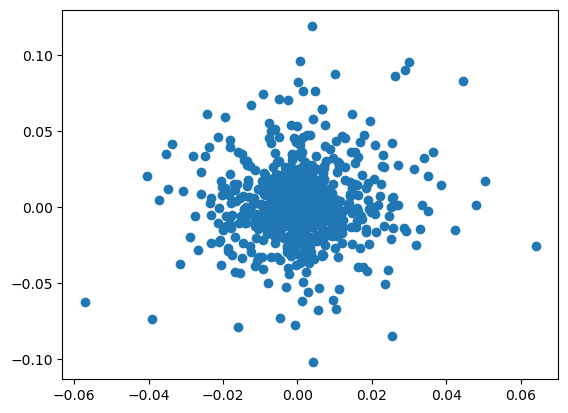

In [21]:
plt.scatter(fac_dict['price_vwap_dev'].keys(), fac_dict['price_vwap_dev'].values())

### 量价背离/量价同向 因子 (Price-Volume Divergence/Convergence Factor)

下面的单元格计算一个简单的量价因子：将日收益与日成交量变化进行 zscore 归一化并相乘。因子为正表示价量同向（同向），为负表示价量背离（背离）。随后计算因子与次日收益的相关性并做一个简单的策略回测。

In [22]:
# price-volume hourly correlation (fixed)
import pandas as pd
import numpy as np

def hourly_price_vol_corr(df_hour):
    close_ret = df_hour['Close'].ffill().pct_change()
    vol_ret = df_hour['Volume'].ffill().pct_change()
    if close_ret.dropna().shape[0] < 2 or vol_ret.dropna().shape[0] < 2:
        return np.nan
    return close_ret.corr(vol_ret)

pv_hour = data_df.set_index('datetime_et').resample('H').apply(hourly_price_vol_corr)
pv_hour_df = pv_hour.to_frame(name='price_vol_corr')
pv_hour_df = pv_hour_df.dropna().copy()

In [23]:
pv_hour_cat_df = pv_hour_df.merge(analysis_df[['next_day_return','next_trade_day_ret']], left_index=True, right_index=True, how='inner')

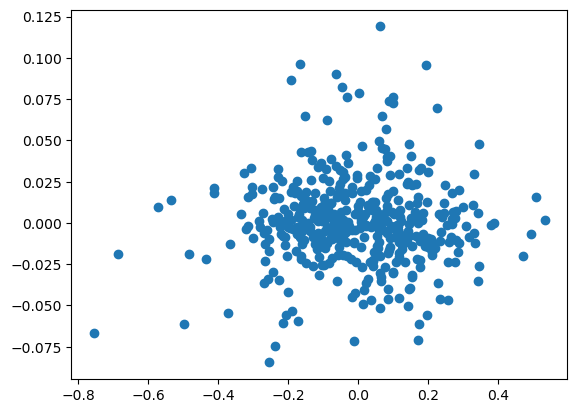

In [24]:
plt.scatter(pv_hour_cat_df['price_vol_corr'], pv_hour_cat_df['next_day_return'])

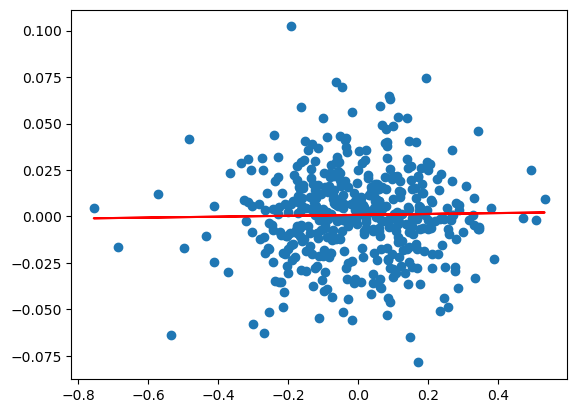

In [25]:
plt.scatter(pv_hour_cat_df['price_vol_corr'], pv_hour_cat_df['next_trade_day_ret'])
# fit a linear line
from sklearn.linear_model import LinearRegression
X = pv_hour_cat_df['price_vol_corr'].values.reshape(-1, 1)
y = pv_hour_cat_df['next_trade_day_ret'].values
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
plt.plot(X, y_pred, color='red')

### Time-dependent Price Bounds (volume-aware)

The cell below computes hourly upper/lower bounds based on rolling price volatility (hourly returns) scaled by recent volume z-score. Higher-than-normal volume widens the bounds; lower volume tightens them. We then detect breaches where price moves outside these bounds.

Total hours analyzed: 17358, breaches: 1180 (upper: 606, lower: 574)


Total hours analyzed: 17358, breaches: 1180 (upper: 606, lower: 574)


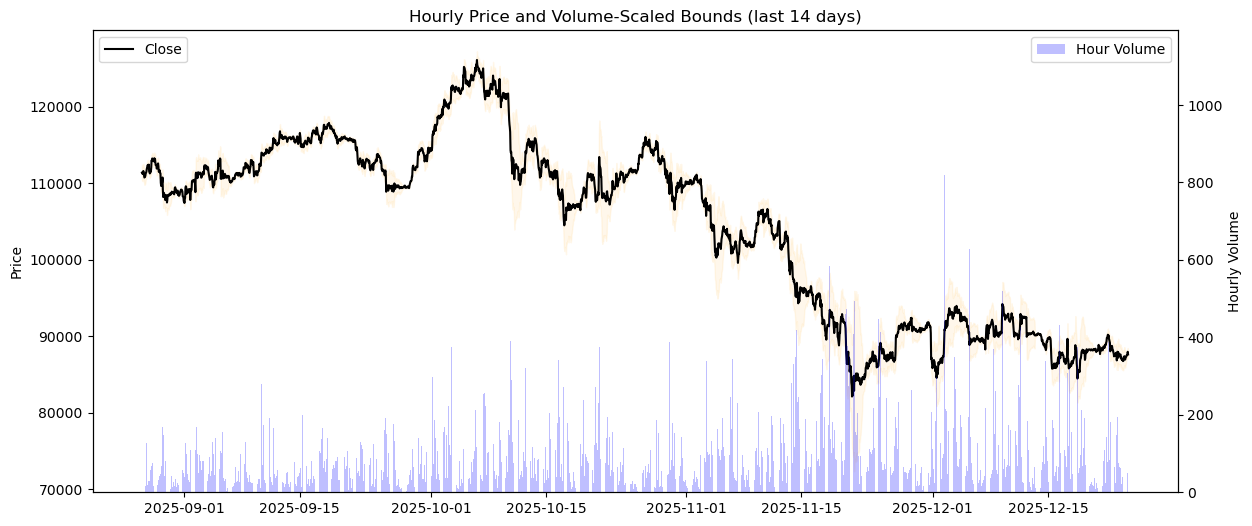

Total hours analyzed: 17358, breaches: 1180 (upper: 606, lower: 574)


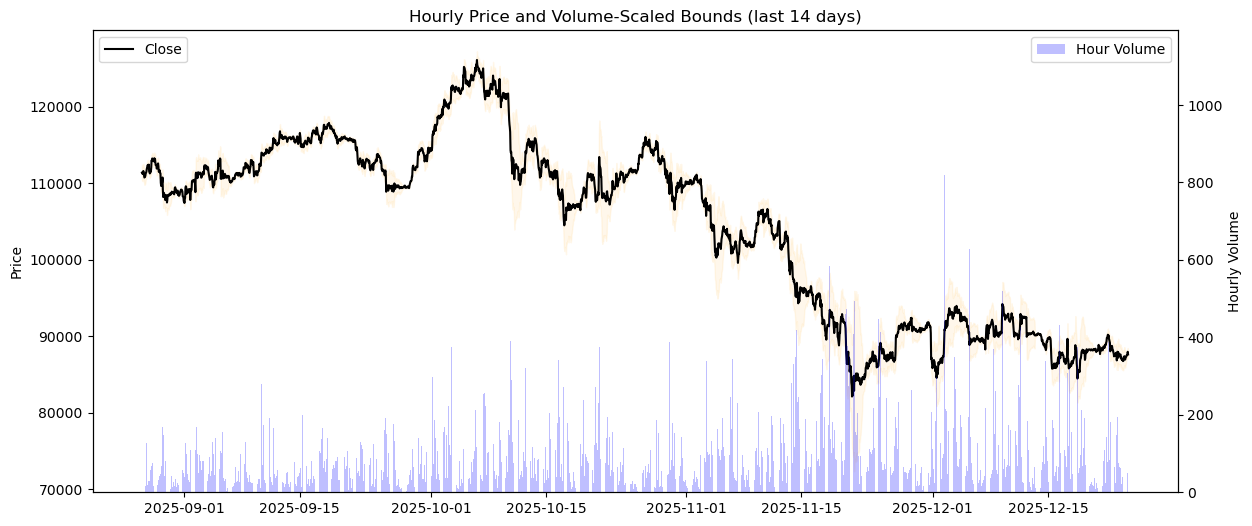

Recent breach examples (last 10):
                             Close  next_close         upper         lower  \
datetime_et                                                                  
2025-12-15 08:00:00-05:00  89433.0     88045.0  90294.425501  88571.574499   
2025-12-17 08:00:00-05:00  87618.0     89639.0  89104.525585  86131.474415   
2025-12-17 09:00:00-05:00  89639.0     87200.0  91678.040881  87599.959119   
2025-12-20 19:00:00-05:00  88345.0     87994.0  88428.540591  88261.459409   
2025-12-21 02:00:00-05:00  88152.0     88501.0  88282.112488  88021.887512   
2025-12-21 03:00:00-05:00  88501.0     88846.0  88668.006922  88333.993078   
2025-12-21 04:00:00-05:00  88846.0     88623.0  89052.299070  88639.700930   
2025-12-21 07:00:00-05:00  88605.0     87649.0  88821.325701  88388.674299   
2025-12-21 08:00:00-05:00  87649.0     88038.0  88032.267274  87265.732726   
2025-12-22 13:00:00-05:00  89105.0     88011.0  89934.792738  88275.207262   

                             

Total hours analyzed: 17358, breaches: 1180 (upper: 606, lower: 574)


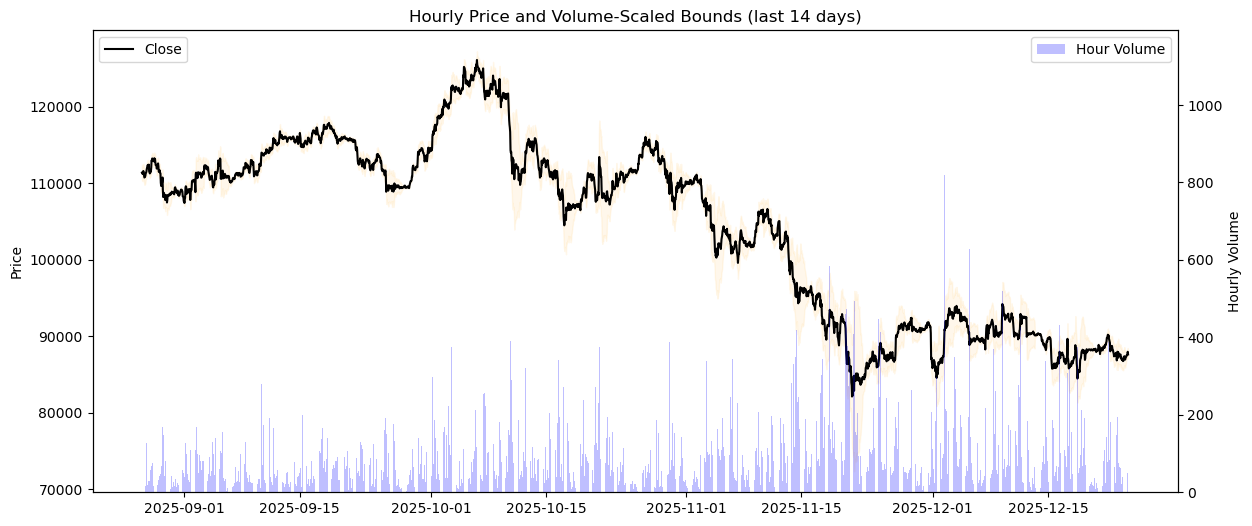

Recent breach examples (last 10):
                             Close  next_close         upper         lower  \
datetime_et                                                                  
2025-12-15 08:00:00-05:00  89433.0     88045.0  90294.425501  88571.574499   
2025-12-17 08:00:00-05:00  87618.0     89639.0  89104.525585  86131.474415   
2025-12-17 09:00:00-05:00  89639.0     87200.0  91678.040881  87599.959119   
2025-12-20 19:00:00-05:00  88345.0     87994.0  88428.540591  88261.459409   
2025-12-21 02:00:00-05:00  88152.0     88501.0  88282.112488  88021.887512   
2025-12-21 03:00:00-05:00  88501.0     88846.0  88668.006922  88333.993078   
2025-12-21 04:00:00-05:00  88846.0     88623.0  89052.299070  88639.700930   
2025-12-21 07:00:00-05:00  88605.0     87649.0  88821.325701  88388.674299   
2025-12-21 08:00:00-05:00  87649.0     88038.0  88032.267274  87265.732726   
2025-12-22 13:00:00-05:00  89105.0     88011.0  89934.792738  88275.207262   

                             

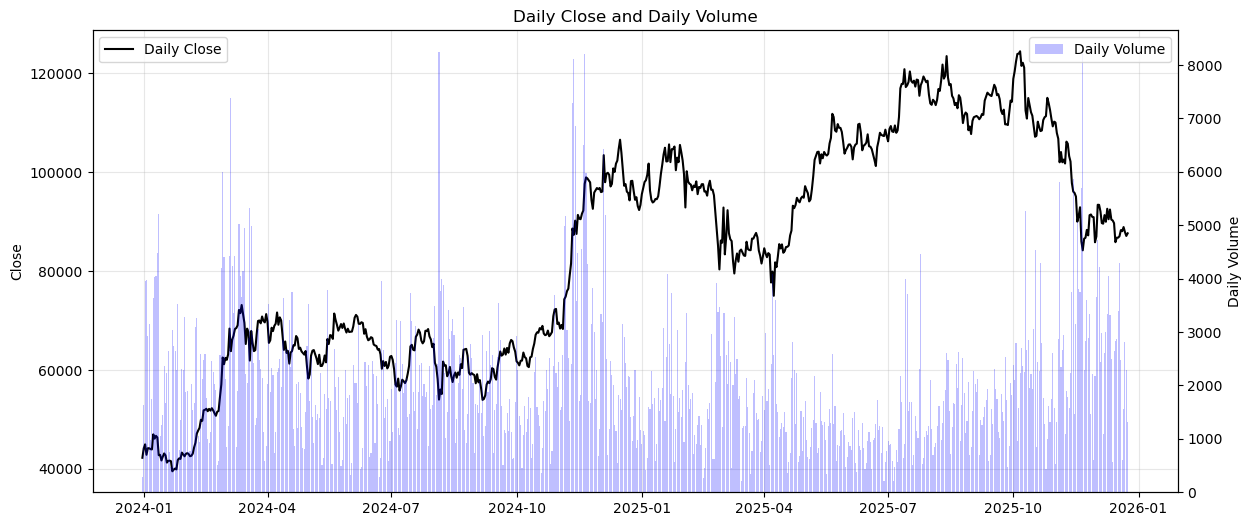

In [26]:
# Time-dependent bounds (hourly) with volume scaling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Build hourly series (close and volume)
hourly = data_df.set_index('datetime_et').resample('H').agg({'Close':'last','Volume':'sum'}).dropna()
hourly['hour_ret'] = hourly['Close'].pct_change()

# Rolling stats (use past 24 hours by default) -- tune window as needed
roll_w = 24
hourly['roll_std'] = hourly['hour_ret'].rolling(roll_w).std()
hourly['roll_vol'] = hourly['Volume'].rolling(roll_w).mean()
# compute volume zscore on rolling mean (avoid NaNs)
hourly['vol_z'] = zscore(hourly['roll_vol'].fillna(method='ffill').fillna(0))

# scaling params: k controls baseline multiple of std, gamma controls how much vol_z inflates bounds
k = 3.0
gamma = 0.5
# guard vol_z extreme values and compute scale factor >= 0.2 to avoid collapse
hourly['scale'] = (1.0 + gamma * hourly['vol_z']).clip(lower=0.2)

# bounds as percentage moves around current close
hourly['bound_pct'] = k * hourly['roll_std'] * hourly['scale']
hourly['upper'] = hourly['Close'] * (1 + hourly['bound_pct'])
hourly['lower'] = hourly['Close'] * (1 - hourly['bound_pct'])

# Detect breaches in the next hour (compare next hour close to current bounds)
hourly['next_close'] = hourly['Close'].shift(-1)
hourly['breach_upper'] = hourly['next_close'] > hourly['upper']
hourly['breach_lower'] = hourly['next_close'] < hourly['lower']
hourly['breach_any'] = hourly['breach_upper'] | hourly['breach_lower']

# Summary stats
total_hours = len(hourly)
breaches = hourly['breach_any'].sum()
upper_b = hourly['breach_upper'].sum()
lower_b = hourly['breach_lower'].sum()
print(f'Total hours analyzed: {total_hours}, breaches: {breaches} (upper: {upper_b}, lower: {lower_b})')

# Show recent period with bounds, using twin y-axis for volume
show_period = hourly.last('120D')
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(show_period.index, show_period['Close'], label='Close', color='black')
#ax1.plot(show_period.index, show_period['upper'], label='Upper bound', color='red', alpha=0.7)
#ax1.plot(show_period.index, show_period['lower'], label='Lower bound', color='green', alpha=0.7)
ax1.fill_between(show_period.index, show_period['lower'], show_period['upper'], color='orange', alpha=0.08)
ax1.set_ylabel('Price')
ax1.set_title('Hourly Price and Volume-Scaled Bounds (last 14 days)')
ax1.legend(loc='upper left')

# secondary axis for hourly volume
ax2 = ax1.twinx()
ax2.bar(show_period.index, show_period['Volume'], width=0.03, alpha=0.25, color='blue', label='Hour Volume')
ax2.set_ylabel('Hourly Volume')
ax2.legend(loc='upper right')
plt.show()

# Print a few breach examples
examples = hourly[hourly['breach_any']].sort_index().tail(10)[['Close','next_close','upper','lower','vol_z','bound_pct','breach_upper','breach_lower']]
print('Recent breach examples (last 10):')
print(examples)

# Save to analysis_df for downstream use
analysis_bounds = hourly[['Close','upper','lower','bound_pct','vol_z','breach_upper','breach_lower','breach_any']].copy()

# Plot daily close and daily volume (twin y-axis)
daily_plot_df = daily_df.copy()
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(daily_plot_df.index, daily_plot_df['Close'], color='black', label='Daily Close')
ax1.set_ylabel('Close')
ax1.set_title('Daily Close and Daily Volume')
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.bar(daily_plot_df.index, daily_plot_df['total_daily_volume'], alpha=0.25, color='blue', label='Daily Volume')
ax2.set_ylabel('Daily Volume')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()


### Detect Price-Volume Spike Events

Mark hours where a sharp price move (z-scored) coincides with a sharp volume increase. We'll compute rolling z-scores for hourly returns and hourly volume, flag spikes, classify direction, and plot them.

PV spike events detected: 377
down    205
up      172
Name: pv_dir, dtype: int64


PV spike events detected: 377
down    205
up      172
Name: pv_dir, dtype: int64


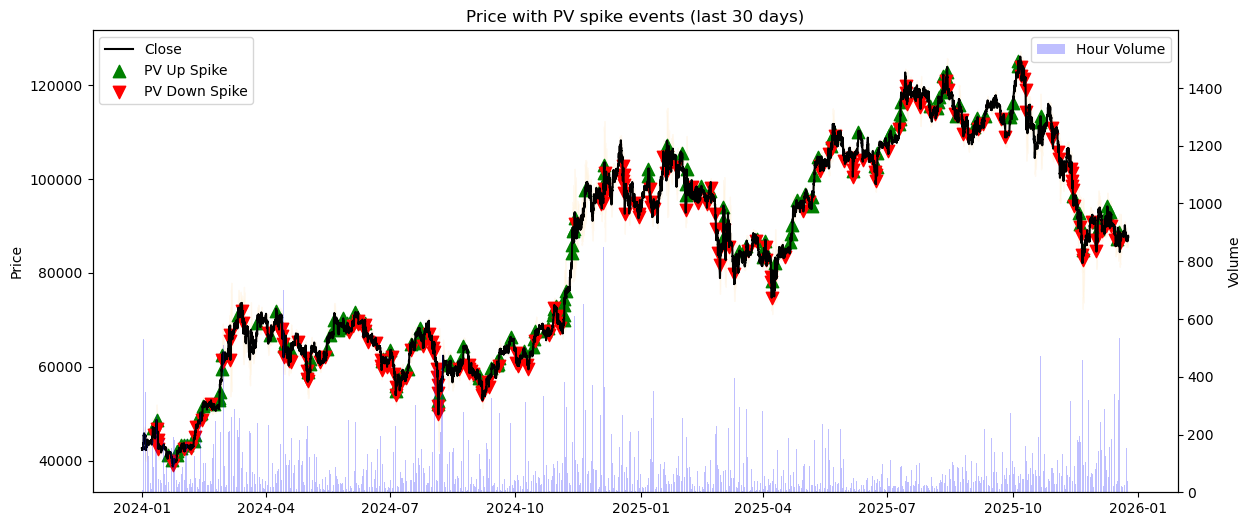

Recent PV spike events (last 50):
                              Close  hour_ret   price_z      Volume     vol_z  \
datetime_et                                                                     
2025-09-09 10:00:00-04:00  111773.0 -0.008850 -2.686603  200.181332  2.673156   
2025-09-10 08:00:00-04:00  113422.0  0.010090  2.903703  220.392868  3.046888   
2025-09-22 02:00:00-04:00  112898.0 -0.007455 -3.271668  251.583619  3.288811   
2025-09-25 13:00:00-04:00  108878.0 -0.019055 -6.714456  333.169873  5.008291   
2025-09-29 09:00:00-04:00  113281.0  0.010797  3.545218  238.909062  3.124759   
2025-09-29 10:00:00-04:00  114100.0  0.007230  2.319805  273.596761  3.584402   
2025-10-01 04:00:00-04:00  116137.0  0.013580  4.137834  297.432717  3.751188   
2025-10-04 22:00:00-04:00  124107.0  0.013557  4.112789  283.744897  2.851600   
2025-10-05 00:00:00-04:00  125209.0  0.010948  3.152609  282.339587  2.751029   
2025-10-07 09:00:00-04:00  123993.0 -0.008119 -2.526559  254.601729  2.2616

In [27]:
# Detect price-volume spike events (hourly)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# ensure `hourly` exists (created by bounds cell); recompute if missing
try:
    hourly
except NameError:
    hourly = data_df.set_index('datetime_et').resample('H').agg({'Close':'last','Volume':'sum'}).dropna()
    hourly['hour_ret'] = hourly['Close'].pct_change()

# rolling window for zscore (hours). tune as needed (e.g., 168 = 1 week)
rz_w = 168
hourly['price_mean'] = hourly['hour_ret'].rolling(rz_w).mean()
hourly['price_std'] = hourly['hour_ret'].rolling(rz_w).std()
hourly['vol_mean'] = hourly['Volume'].rolling(rz_w).mean()
hourly['vol_std'] = hourly['Volume'].rolling(rz_w).std()

# compute rolling z-scores, guard div-by-zero
hourly['price_z'] = (hourly['hour_ret'] - hourly['price_mean']) / hourly['price_std']
hourly['vol_z'] = (hourly['Volume'] - hourly['vol_mean']) / hourly['vol_std']

# thresholds for detection (tunable)
price_z_thresh = 2.0
vol_z_thresh = 2.0

# flag events where abs(price_z) > thresh and vol_z > thresh
hourly['pv_spike'] = (hourly['price_z'].abs() >= price_z_thresh) & (hourly['vol_z'] >= vol_z_thresh)
hourly['pv_dir'] = np.where(hourly['pv_spike'], np.where(hourly['price_z']>0, 'up', 'down'), None)

# summary
n_spikes = hourly['pv_spike'].sum()
print(f'PV spike events detected: {n_spikes}')
print(hourly['pv_dir'].value_counts(dropna=True))

# plot recent period with events marked
show = hourly.last('1000D').copy()
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(show.index, show['Close'], color='black', label='Close')
ax1.fill_between(show.index, show['lower'], show['upper'], color='orange', alpha=0.06) if 'lower' in show.columns and 'upper' in show.columns else None
# mark up spikes and down spikes
ups = show[show['pv_dir']=='up']
downs = show[show['pv_dir']=='down']
ax1.scatter(ups.index, ups['Close'], marker='^', color='green', s=80, label='PV Up Spike')
ax1.scatter(downs.index, downs['Close'], marker='v', color='red', s=80, label='PV Down Spike')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(show.index, show['Volume'], width=0.03, alpha=0.25, color='blue', label='Hour Volume')
ax2.set_ylabel('Volume')
ax2.legend(loc='upper right')
plt.title('Price with PV spike events (last 30 days)')
plt.show()

# show table of recent events
events_table = hourly[hourly['pv_spike']].sort_index().tail(50)[['Close','hour_ret','price_z','Volume','vol_z','pv_dir']]
print('Recent PV spike events (last 50):')
print(events_table)

# save events for downstream usage
pv_events = hourly[hourly['pv_spike']].copy()


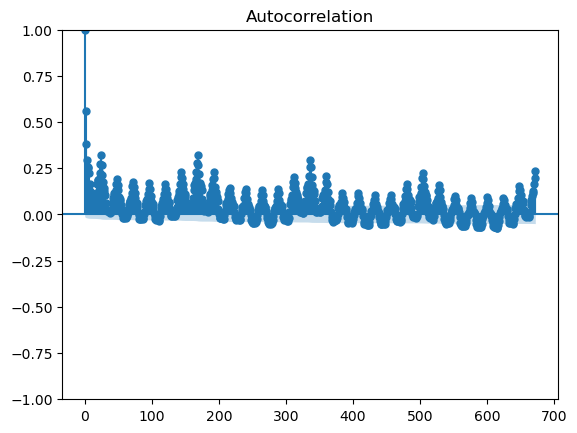

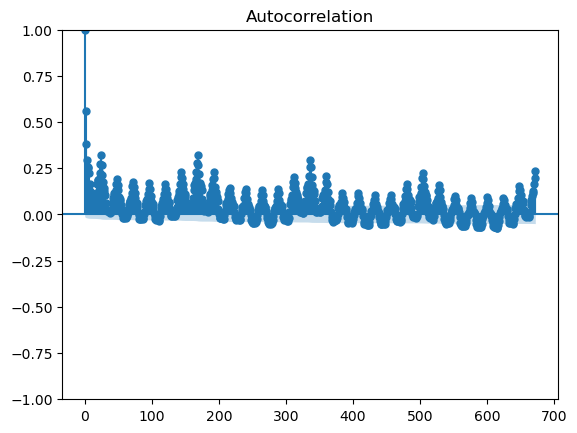

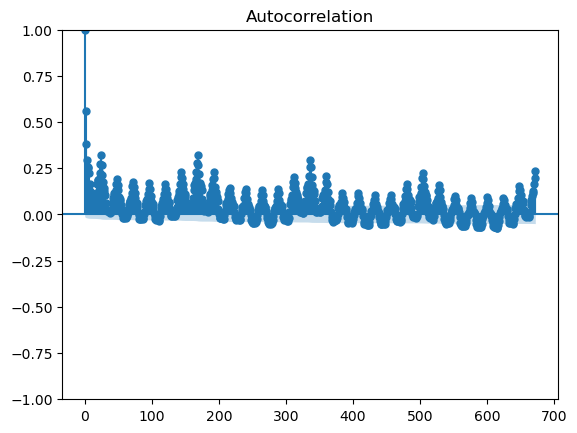

In [28]:
# Detect daily volume outliers and correlate with next 1-week return
import numpy as np
from scipy.stats import zscore

hourly_volume = data_df.set_index('datetime_et').resample('H').agg({'Volume':'sum','Close':'last'}).dropna()
plot_acf(hourly_volume['Volume'], lags=168*4)  # 168 hours = 1 week


In [29]:
# compare with 24 hours ago - daily pattern
# compare with 7 (169 hours) days ago - weekly pattern
# z score of the same hour over past 7 days
def daily_weekly_vol_zscore(df_hourly, window_days=7):
    df_hourly = df_hourly.copy()
    df_hourly['hour_of_day'] = df_hourly.index.hour
    z_scores = []
    for idx, row in df_hourly.iterrows():
        hour = row.name.hour
        past_data = df_hourly[(df_hourly.index < idx) & (df_hourly.index.hour == hour)].tail(window_days)
        if len(past_data) < 2:
            z_scores.append(np.nan)
            continue
        mean_vol = past_data['Volume'].mean()
        std_vol = past_data['Volume'].std()
        if std_vol == 0:
            z_scores.append(0.0)
        else:
            z = (row['Volume'] - mean_vol) / std_vol
            z_scores.append(z)
    return pd.Series(z_scores, index=df_hourly.index, name='vol_zscore_weekly')
hourly_vol_df = hourly_volume.copy()
hourly_vol_df['vol_zscore_weekly'] = daily_weekly_vol_zscore(hourly_vol_df, window_days=7)
# z score of the same hour of the same day over past 4 weeks
def monthly_vol_zscore(df_hourly, window_weeks=4):
    df_hourly = df_hourly.copy()
    df_hourly['hour_of_day'] = df_hourly.index.hour
    df_hourly['day_of_week'] = df_hourly.index.dayofweek
    z_scores = []
    for idx, row in df_hourly.iterrows():
        hour = row.name.hour
        day = row.name.dayofweek
        past_data = df_hourly[(df_hourly.index < idx) & (df_hourly.index.hour == hour) & (df_hourly.index.dayofweek == day)].tail(window_weeks)
        if len(past_data) < 2:
            z_scores.append(np.nan)
            continue
        mean_vol = past_data['Volume'].mean()
        std_vol = past_data['Volume'].std()
        if std_vol == 0:
            z_scores.append(0.0)
        else:
            z = (row['Volume'] - mean_vol) / std_vol
            z_scores.append(z)
    return pd.Series(z_scores, index=df_hourly.index, name='vol_zscore_monthly')
hourly_vol_df['vol_zscore_monthly'] = monthly_vol_zscore(hourly_vol_df, window_weeks=4)
# rolling max hourly volume over past 120 days
hourly_vol_df['rolling_max_7d'] = hourly_vol_df['Volume'].shift(9).rolling(window=7*24).max()
hourly_vol_df['pct_of_rolling_max'] = hourly_vol_df['Volume'] / hourly_vol_df['rolling_max_7d']
# if the volume is less than 50% of rolling max, set zscore to 0
hourly_vol_df['vol_zscore_weekly'] = np.where(hourly_vol_df['pct_of_rolling_max'] < 0.5, 0.0, hourly_vol_df['vol_zscore_weekly'])
hourly_vol_df['vol_zscore_monthly'] = np.where(hourly_vol_df['pct_of_rolling_max'] < 0.5, 0.0, hourly_vol_df['vol_zscore_monthly'])

#hourly correlation between price return and volume change
def hourly_price_vol_corr(df_hour):
    close_ret = df_hour['Close'].ffill().pct_change()
    vol_ret = df_hour['Volume'].ffill().pct_change()
    if close_ret.dropna().shape[0] < 2 or vol_ret.dropna().shape[0] < 2:
        return np.nan
    return close_ret.corr(vol_ret)
hourly_vol_df['price_vol_corr'] = data_df.set_index('datetime_et')[['Close','Volume']].resample('H').apply(hourly_price_vol_corr)
hourly_vol_df['hour_return'] = data_df.set_index('datetime_et').resample('H')['Close'].last().pct_change()

In [30]:
hourly_vol_df['hour_return_confirmed_by_pv_corr'] = np.where((hourly_vol_df['price_vol_corr'] > 0.0), hourly_vol_df['hour_return'], 0)
hourly_vol_df['hour_return_confirmed_by_pv_corr'] = hourly_vol_df['hour_return_confirmed_by_pv_corr'].shift(1)

In [31]:
hourly_vol_df['min_zscore'] = hourly_vol_df[['vol_zscore_weekly','vol_zscore_monthly']].min(axis=1)

In [32]:
hourly_vol_df.sort_values('min_zscore', ascending=False).head(10)

,Volume,Close,vol_zscore_weekly,vol_zscore_monthly,rolling_max_7d,pct_of_rolling_max,price_vol_corr,hour_return,hour_return_confirmed_by_pv_corr,min_zscore
datetime_et,,,,,,,,,,
2025-07-25 00:00:00-04:00,948.564024,116134.0,107.978260,257.061453,290.873055,3.261093,0.184162,0.006360,-0.008761,107.978260
2025-10-10 17:00:00-04:00,1136.082559,113974.0,60.899531,102.221185,430.862250,2.636765,-0.059189,-0.002817,0.000000,60.899531
2025-07-14 22:00:00-04:00,1215.176054,118114.0,40.532791,35.685845,565.330156,2.149498,-0.088711,-0.002609,0.000000,35.685845
2025-07-25 04:00:00-04:00,726.710956,115153.0,27.076751,30.766237,290.873055,2.498378,0.297678,-0.001526,-0.000095,27.076751
2025-01-20 01:00:00-05:00,496.745694,107272.0,28.999093,26.903973,494.365457,1.004815,0.189196,0.049320,0.000000,26.903973
2024-11-05 23:00:00-05:00,631.640537,74282.0,26.682212,33.056815,490.738163,1.287123,0.160502,-0.000888,0.017114,26.682212
2025-07-14 21:00:00-04:00,743.235637,118423.0,53.342081,22.033978,565.330156,1.314693,-0.166421,-0.008996,0.000000,22.033978
2024-01-09 21:00:00-05:00,1523.541942,45462.0,21.363383,NaN,1505.468190,1.012005,0.337034,-0.025800,-0.004777,21.363383
2024-11-05 19:00:00-05:00,586.172554,71118.0,19.648509,29.320861,490.738163,1.194471,0.183059,0.024962,-0.002874,19.648509


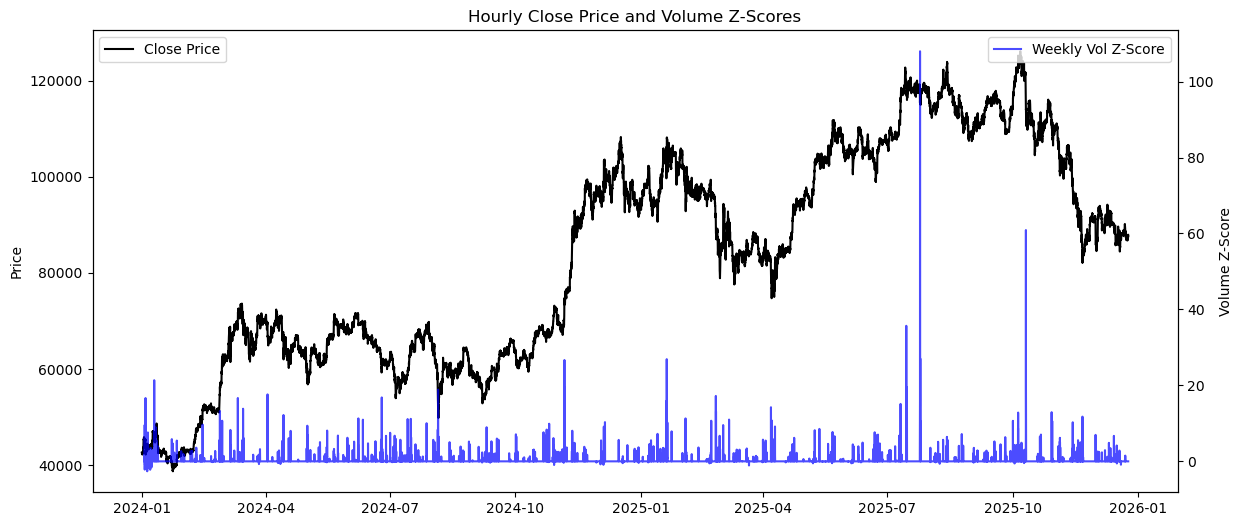

In [33]:
# plot price and volume zscores
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(hourly_vol_df.index, hourly_vol_df['Close'], color='black', label='Close Price')
ax1.set_ylabel('Price') 
ax1.set_title('Hourly Close Price and Volume Z-Scores')
ax2 = ax1.twinx()   
ax2.plot(hourly_vol_df.index, hourly_vol_df[['vol_zscore_weekly','vol_zscore_monthly']].min(axis=1), color='blue', label='Weekly Vol Z-Score', alpha=0.7)
#ax2.plot(hourly_vol_df.index, hourly_vol_df['vol_zscore_monthly'], color='orange', label='Monthly Vol Z-Score', alpha=0.7)
ax2.set_ylabel('Volume Z-Score')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

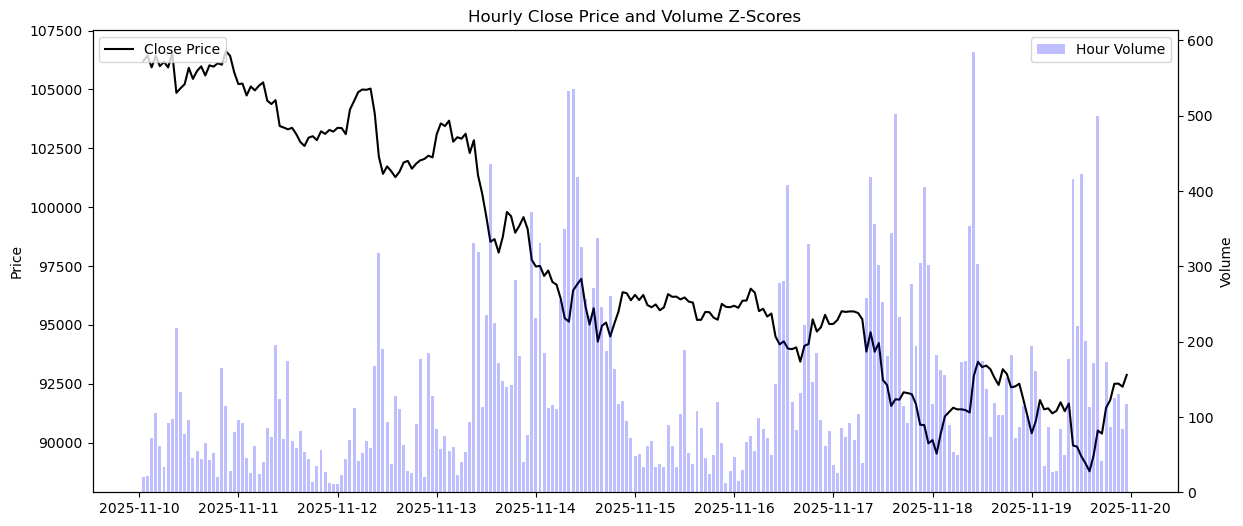

In [46]:
# plot hour close and volume against time
# define mask for date range (handle tz-aware index)
tz = getattr(hourly_vol_df.index, 'tz', None)
start = pd.Timestamp('2025-11-10', tz=tz)
end = pd.Timestamp('2025-11-20', tz=tz)
mask = (hourly_vol_df.index > start) & (hourly_vol_df.index < end)
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(hourly_vol_df[mask].index, hourly_vol_df.loc[mask,'Close'], color='black', label='Close Price')
ax1.set_ylabel('Price')
ax1.set_title('Hourly Close Price and Volume Z-Scores')
ax2 = ax1.twinx()   
ax2.bar(hourly_vol_df[mask].index, hourly_vol_df.loc[mask,'Volume'], width=0.03, alpha=0.25, color='blue', label='Hour Volume')
ax2.set_ylabel('Volume')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [35]:
hourly_vol_df[mask]

,Volume,Close,vol_zscore_weekly,vol_zscore_monthly,rolling_max_7d,pct_of_rolling_max,price_vol_corr,hour_return,hour_return_confirmed_by_pv_corr,min_zscore
datetime_et,,,,,,,,,,
2025-10-15 01:00:00-04:00,32.279958,112491.0,0.0,0.0,1136.082559,0.028413,0.009282,0.000810,0.002882,0.0
2025-10-15 02:00:00-04:00,68.596699,112502.0,0.0,0.0,1136.082559,0.060380,-0.017353,0.000098,0.000810,0.0
2025-10-15 03:00:00-04:00,64.411979,112643.0,0.0,0.0,1136.082559,0.056697,0.213921,0.001253,0.000000,0.0
2025-10-15 04:00:00-04:00,57.380958,113019.0,0.0,0.0,1136.082559,0.050508,0.361989,0.003338,0.001253,0.0
2025-10-15 05:00:00-04:00,97.501096,112637.0,0.0,0.0,1136.082559,0.085822,-0.435697,-0.003380,0.003338,0.0
...,...,...,...,...,...,...,...,...,...,...
2025-12-24 14:00:00-05:00,30.642279,87494.0,0.0,0.0,630.700793,0.048584,0.023246,0.000961,0.001811,0.0
2025-12-24 15:00:00-05:00,29.029559,87488.0,0.0,0.0,630.700793,0.046027,-0.181430,-0.000069,0.000961,0.0
2025-12-24 16:00:00-05:00,50.388651,87634.0,0.0,0.0,630.700793,0.079893,0.164127,0.001669,0.000000,0.0


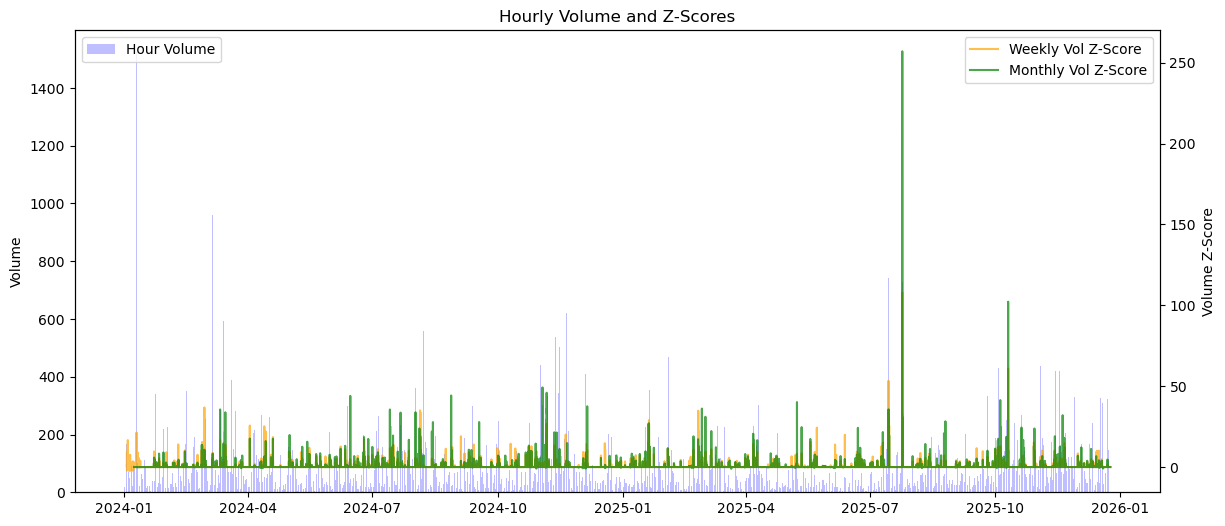

In [36]:
# plot volume and zscored volume against time
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.bar(hourly_vol_df.index, hourly_vol_df['Volume'], width=0.03, alpha=0.25, color='blue', label='Hour Volume')
ax1.set_ylabel('Volume')
ax1.set_title('Hourly Volume and Z-Scores')
ax2 = ax1.twinx()
ax2.plot(hourly_vol_df.index, hourly_vol_df['vol_zscore_weekly'], color='orange', label='Weekly Vol Z-Score', alpha=0.7)
ax2.plot(hourly_vol_df.index, hourly_vol_df['vol_zscore_monthly'], color='green', label='Monthly Vol Z-Score', alpha=0.7)
ax2.set_ylabel('Volume Z-Score')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [37]:
# Calculate RSI on hourly data
delta = hourly_vol_df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14*24).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14*24).mean()
rs = gain / loss
hourly_vol_df['rsi'] = 100 - (100 / (1 + rs))
hourly_vol_df['rsi'] = hourly_vol_df['rsi'].fillna(50) # fill NaNs with neutral 50
print("RSI (14-hour) calculated and added to the dataframe.")

RSI (14-hour) calculated and added to the dataframe.


In [48]:
# Backtest: when `min_zscore > 20` then if previous 7-day return < 0 go long, else short; stop at 5% profit or 7-day scheduled exit; sequential trades, $10k principal
import pandas as pd
import numpy as np

principal = 10000.0
tz = getattr(hourly_vol_df.index, 'tz', None)
start = pd.Timestamp('2025-10-15', tz=tz)
df = hourly_vol_df.sort_index().copy()
df = df[df.index >= start].copy()
if df.empty:
    print('No data from start date')
else:
    trades = []
    capital = principal
    capital_hist = [(df.index[0], capital)]
    i = 0
    idx_index = df.index
    n = len(df)
    z_th =5
    # default values
    stop_gain_pct = 0.05
    stop_loss_pct = 0.05
    # long trade exit time
    long_exit_days_int = 7
    short_exit_days_int = 7
    # cycle statis collection dict
    cycle_df = pd.DataFrame(columns=['best_short_pct','best_short_entry_price','best_short_exit_price','best_short_holding_time',
                                 'best_long_pct','best_long_entry_price','best_long_exit_price','best_long_holding_time'])
    while i < n:
        t = idx_index[i]
        row = df.iloc[i]
        # collect statistics for cycling movement and upper and lower bounds
        # collect best buy/sell points in the previous 21 days
      
        # best short trade points
        past_df = df[(df.index < t) & (df.index >= t - pd.Timedelta(days=21))].copy()
        #find accum max from the start
        past_df['accum_max'] = past_df['Close'].cummax()
        past_df['accum_future_min'] = past_df['Close'][::-1].cummin()[::-1]
        past_df['potential_short_pct'] = (past_df['accum_max'] - past_df['accum_future_min']) / past_df['accum_max']
        best_short = past_df['potential_short_pct'].max()
        best_short_time = past_df['potential_short_pct'].idxmax() if not past_df['potential_short_pct'].empty else None
        best_short_entry_price = past_df.loc[best_short_time, 'accum_max'] if best_short_time is not None else np.nan
        best_short_exit_price = past_df.loc[best_short_time, 'accum_future_min'] if best_short_time is not None else np.nan
        best_short_holding_days_int = (past_df.loc[best_short_time:, 'potential_short_pct'].idxmin() - best_short_time).days if best_short_time is not None else 7
        
        # best long trade points
        past_df['accum_min'] = past_df['Close'].cummin()
        past_df['accum_future_max'] = past_df['Close'][::-1].cummax()[::-1]
        past_df['potential_long_pct'] = (past_df['accum_future_max'] - past_df['accum_min']) / past_df['accum_min']
        best_long = past_df['potential_long_pct'].max()
        best_long_time = past_df['potential_long_pct'].idxmax() if not past_df['potential_long_pct'].empty else None
        best_long_entry_price = past_df.loc[best_long_time, 'accum_min'] if best_long_time is not None else np.nan
        best_long_exit_price = past_df.loc[best_long_time, 'accum_future_max'] if best_long_time is not None else np.nan
        best_long_holding_days_int = (past_df.loc[best_long_time:, 'potential_long_pct'].idxmin() - best_long_time).days if best_long_time is not None else 7
        # record in cycle_df
        cycle_df.loc[t] = [best_short, best_short_entry_price, best_short_exit_price,best_short_holding_days_int,
                            best_long, best_long_entry_price, best_long_exit_price,best_long_holding_days_int]
        if i> 21*24:
            # update stop gain/loss pct and exit days based on rolling mean of cycle stats
            stop_gain_pct = cycle_df['best_long_pct'].rolling(window=21*24).mean().iloc[-1] if not cycle_df['best_long_pct'].rolling(window=21*24).mean().empty else 0.05
            stop_gain_pct = min(stop_gain_pct, 0.1)  # minimum 10% gain target
            stop_loss_pct = cycle_df['best_short_pct'].rolling(window=21*24).mean().iloc[-1] if not cycle_df['best_short_pct'].rolling(window=21*24).mean().empty else 0.05
            stop_loss_pct = min(stop_loss_pct, 0.1)  # minimum 10% loss limit
            long_exit_days_int = int(cycle_df['best_long_holding_time'].ffill().rolling(window=21*24,min_periods=7*24).mean().iloc[-1]) if not cycle_df['best_long_holding_time'].rolling(window=21*24).mean().empty else 7
            long_exit_days_int = max(long_exit_days_int, 3)  # minimum 3 days exit
            short_exit_days_int = int(cycle_df['best_short_holding_time'].ffill().rolling(window=21*24,min_periods=7*24).mean().iloc[-1]) if not cycle_df['best_short_holding_time'].rolling(window=21*24).mean().empty else 7
            short_exit_days_int = max(short_exit_days_int, 3)  # minimum 3 days exit
        # check for trade signal
        if row.get('min_zscore', 0) > z_th:
            # determine side using RSI
            rsi_value = row.get('rsi', 50)  # Default to neutral if RSI is not available
            if rsi_value < 30:
                side = 1  # RSI indicates oversold, go long
            elif rsi_value > 70:
                side = -1  # RSI indicates overbought, go short
            else:
                i += 1
                continue  # No clear signal from RSI
            # if side ==-1:
            #     i+=1
            #     continue  # skip short trades for now
            # if np.sign(side)=np.sign(row.get('hour_return_confirmed_by_pv_corr', 0)):
            #     i+=1
            #     continue  # skip if not confirmed by price-volume correlation
            # entry at next available hour and scheduled exit after 7 days (target)
            if i + 1 >= n:
                break
            entry_idx = i + 1
            entry_time = idx_index[entry_idx]
            entry_price = df.loc[entry_time, 'Close']
            
            stop_idx = None
            j = entry_idx + 1
            recommeded_exit_idx = None
            if side ==1:
                recommeded_exit_idx = min(entry_idx + long_exit_days_int*24, n-1)
            else:
                recommeded_exit_idx = min(entry_idx + short_exit_days_int*24, n-1)
            while (j< n):
                if j >= recommeded_exit_idx:
                    stop_idx = recommeded_exit_idx
                    break
                 # check stop gain/loss
                cur_price = df.iloc[j]['Close']
                cur_pct = (cur_price / entry_price - 1) * side
                if cur_pct >= stop_gain_pct or cur_pct <= -stop_loss_pct:
                    stop_idx = j 
                    break
                # check for zscore signal in between

                cur_z = df.iloc[j]['min_zscore']
                if cur_z > z_th and np.sign(side) != np.sign(cur_pct): # same direction of signal
                    stop_idx = j+12  # exit after 12 hours
                    break
                j += 1
                
                
            exit_time = idx_index[stop_idx]
            exit_price = df.loc[exit_time, 'Close']
            pct = (exit_price / entry_price - 1) * side
            capital = capital * (1 + pct)
            trades.append({
                
                'min_zscore': row.get('min_zscore', np.nan),
                'entry_time': entry_time, 'hour_return':row.get('hour_return',np.nan),'exit_time': exit_time, 'side': 'long' if side==1 else 'short','last_hour_return_confirmed_by_pv_corr': row.get('hour_return_confirmed_by_pv_corr', np.nan),
                'entry_price': entry_price, 'exit_price': exit_price, 'pct_return': pct, 'capital': capital,
                'stop_loss_pct': stop_loss_pct, 'stop_gain_pct': stop_gain_pct,'recommented_exit_days': long_exit_days_int if side==1 else short_exit_days_int
            })
            capital_hist.append((exit_time, capital))
            # advance i to the first index after exit_time
            i = int(df.index.get_loc(exit_time)) + 1
        else:
            i += 1
    # summarize results
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame(columns=['entry_time'])
    print(f'Total trades: {len(trades_df)}')
    if not trades_df.empty:
        final_cap = capital_hist[-1][1]
        total_ret = final_cap / principal - 1
        start_dt = trades_df['entry_time'].min()
        end_dt = trades_df['exit_time'].max()
        days = (end_dt - start_dt).days if pd.notna(end_dt) and pd.notna(start_dt) else 0
        ann_ret = (final_cap / principal) ** (365 / days) - 1 if days>0 else np.nan
        win_rate = (trades_df['pct_return'] > 0).mean()
        avg_ret = trades_df['pct_return'].mean()
        print(f'Final capital: ${final_cap:,.2f}, total_ret={total_ret:.2%}, ann_ret={ann_ret:.2%}')
        print(f'Win rate: {win_rate:.2%}, avg trade pct: {avg_ret:.2%}')
        display(trades_df.round(4))
    else:
        print('No trades executed under the rules.')

Total trades: 7
Final capital: $10,528.74, total_ret=5.29%, ann_ret=34.16%
Win rate: 57.14%, avg trade pct: 0.88%


,min_zscore,entry_time,hour_return,exit_time,side,last_hour_return_confirmed_by_pv_corr,entry_price,exit_price,pct_return,capital,stop_loss_pct,stop_gain_pct,recommented_exit_days
0,6.5381,2025-10-21 01:00:00-04:00,-0.0117,2025-10-21 11:00:00-04:00,long,-0.0038,107561.0,113420.0,0.0545,10544.7142,0.05,0.0500,7
1,10.6086,2025-10-30 01:00:00-04:00,-0.0197,2025-11-04 00:00:00-05:00,long,-0.0020,110273.0,104178.0,-0.0553,9961.8876,0.05,0.0500,7
2,5.2146,2025-11-04 14:00:00-05:00,0.0025,2025-11-05 04:00:00-05:00,long,0.0000,100465.0,101985.0,0.0151,10112.6075,0.05,0.0500,7
3,7.5558,2025-11-14 00:00:00-05:00,-0.0133,2025-11-18 09:00:00-05:00,long,0.0000,97480.0,91277.0,-0.0636,9469.1062,0.10,0.0853,9
4,11.7719,2025-11-21 05:00:00-05:00,-0.0172,2025-11-26 13:00:00-05:00,long,-0.0046,82594.0,90132.0,0.0913,10333.3109,0.10,0.0893,9
5,6.9685,2025-11-30 20:00:00-05:00,-0.0373,2025-12-10 20:00:00-05:00,long,0.0000,87192.0,90707.0,0.0403,10749.8811,0.10,0.0967,10
6,6.7030,2025-12-14 07:00:00-05:00,-0.0052,2025-12-24 18:00:00-05:00,long,0.0000,89445.0,87605.0,-0.0206,10528.7420,0.10,0.1000,11


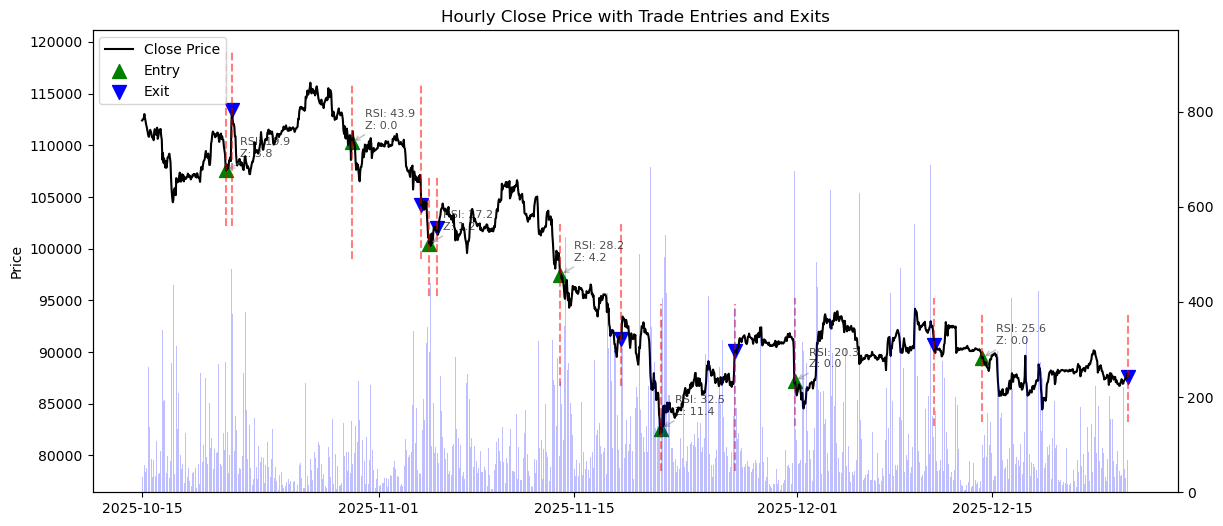

In [51]:
# mark the trades on the price chart using dots
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(df.index, df['Close'], color='black', label='Close Price')
ax2 = ax1.twinx()   
ax2.bar(df.index, df['Volume'], width=0.03, alpha=0.25, color='blue', label='Hour Volume')
for _, trade in trades_df.iterrows():
    entry_time = trade['entry_time']
    exit_time = trade['exit_time']
    entry_price = trade['entry_price']
    exit_price = trade['exit_price']
    ax1.scatter(entry_time, entry_price, marker='^', color='green' if trade['side']=='long' else 'red', s=100, label='Entry' if _==0 else "")
    ax1.scatter(exit_time, exit_price, marker='v', color='blue', s=100, label='Exit' if _==0 else "")
    ax1.vlines(x=[entry_time, exit_time], ymin=.95*min(entry_price, exit_price), ymax=1.05*max(entry_price, exit_price), color='red', linestyle='--', alpha=0.5)
    # add annotation for rsi and min_zscore
    ax1.annotate(f"RSI: {hourly_vol_df.loc[entry_time,'rsi']:.1f}\nZ: {hourly_vol_df.loc[entry_time,'min_zscore']:.1f}", 
                 xy=(entry_time, entry_price), xytext=(10,10), textcoords='offset points', fontsize=8, color='black', alpha=0.7,
                 arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))
ax1.set_ylabel('Price')
ax1.set_title('Hourly Close Price with Trade Entries and Exits')  
ax1.legend(loc='upper left')
plt.show()
